In [90]:
"""
=============================================================================
PROJECT TITLE: REGIONAL PRECIPITATION FORECASTING ACROSS TURKEY VIA 
               SPATIALLY-AWARE DEEP LEARNING NETWORKS
AUTHORS:       İbrahim Şanlıalp - Berke Güngörmez
=============================================================================

DESCRIPTION:
This repository contains the Python implementation of the Spatial CNN-LSTM 
architecture proposed in our study. The primary objective of this codebase 
is to predict daily precipitation occurrences (binary classification: dry 
vs. rainy days) across the seven main geographical regions of Turkey. 

To address the "zero-inflated" nature of isolated station data, this study 
utilizes a spatially-aware deep learning framework. The algorithm operates 
on historical precipitation data and regional adjacency matrices, without 
relying on external meteorological variables.

KEY FEATURES IN THIS CODEBASE:
- Data Aggregation: Processing 5-year daily records (2020-2024) from 1803 
  meteorological stations into regional averages.
- Trigonometric Time Encoding: Converting linear calendar days into a 
  cyclical spatial projection using Sine/Cosine transformations.
- Spatial CNN-LSTM Architecture: Utilizing 1D-Convolutional layers (Conv1D) 
  to extract spatial interactions, coupled with LSTM cells to capture 
  temporal memory.
- Regularization: Implementation of Dropout layers, ReLU activation, and 
  chronological train/validation/test splitting to limit data leakage 
  and overfitting.
  
This code is provided to support the methodological transparency of the 
findings presented in the associated academic paper.
=============================================================================
"""

'\n=============================================================================\nPROJECT TITLE: REGIONAL PRECIPITATION FORECASTING ACROSS TURKEY VIA \n               SPATIALLY-AWARE DEEP LEARNING NETWORKS\nAUTHORS:       İbrahim Şanlıalp - Berke Güngörmez\n=============================================================================\n\nDESCRIPTION:\nThis repository contains the Python implementation of the Spatial CNN-LSTM \narchitecture proposed in our study. The primary objective of this codebase \nis to predict daily precipitation occurrences (binary classification: dry \nvs. rainy days) across the seven main geographical regions of Turkey. \n\nTo address the "zero-inflated" nature of isolated station data, this study \nutilizes a spatially-aware deep learning framework. The algorithm operates \non historical precipitation data and regional adjacency matrices, without \nrelying on external meteorological variables.\n\nKEY FEATURES IN THIS CODEBASE:\n- Data Aggregation: Processing 5

In [1]:
import pandas as pd


data_path = r"C:\Users\Berke Güngörmez\Desktop\sel proje\omgi.txt"
omgi_df = pd.read_csv(data_path, sep='|')

benzersiz_istasyonlar = omgi_df['Istasyon_Adi'].unique()

print(f"Toplam Benzersiz İstasyon Sayısı: {len(benzersiz_istasyonlar)}")
print("\nİlk 20 İstasyon İsmi Örneği:")
for i, istasyon in enumerate(benzersiz_istasyonlar[:20]):
    print(f"{i+1}. {istasyon}")

Toplam Benzersiz İstasyon Sayısı: 1803

İlk 20 İstasyon İsmi Örneği:
1. AK?AKOCA
2. DEVREK/ACISU TEPES? RADAR SAHASI
3. BARTIN
4. ZONGULDAK
5. ZONGULDAK ?AYCUMA HAVAL?MANI
6. ?NEBOLU
7. S?NOP
8. S?NOP HAVAL?MANI
9. SAMSUN B?LGE
10. SAMSUN ?AR?AMBA HAVAL?MANI
11. ORDU
12. G?RESUN
13. TRABZON B?LGE
14. TRABZON HAVAL?MANI
15. R?ZE
16. HOPA
17. R?ZE-ARTV?N HAVAL?MANI
18. ARTV?N
19. ARDAHAN
20. ?ATALCA RADAR SAHASI


In [2]:
import pandas as pd

data_path = r"C:\Users\Berke Güngörmez\Desktop\sel proje\omgi.txt"


omgi_df = pd.read_csv(data_path, sep='|', encoding='cp1254') 


benzersiz_istasyonlar = omgi_df['Istasyon_Adi'].unique()

print(f"Toplam Benzersiz İstasyon Sayısı: {len(benzersiz_istasyonlar)}")
print("\nİlk 20 İstasyon İsmi Örneği (Düzeltilmiş Hal):")
for i, istasyon in enumerate(benzersiz_istasyonlar[:20]):
    print(f"{i+1}. {istasyon}")

Toplam Benzersiz İstasyon Sayısı: 1803

İlk 20 İstasyon İsmi Örneği (Düzeltilmiş Hal):
1. AK?AKOCA
2. DEVREK/ACISU TEPES? RADAR SAHASI
3. BARTIN
4. ZONGULDAK
5. ZONGULDAK ?AYCUMA HAVAL?MANI
6. ?NEBOLU
7. S?NOP
8. S?NOP HAVAL?MANI
9. SAMSUN B?LGE
10. SAMSUN ?AR?AMBA HAVAL?MANI
11. ORDU
12. G?RESUN
13. TRABZON B?LGE
14. TRABZON HAVAL?MANI
15. R?ZE
16. HOPA
17. R?ZE-ARTV?N HAVAL?MANI
18. ARTV?N
19. ARDAHAN
20. ?ATALCA RADAR SAHASI


In [3]:
import re


def istasyon_temizle(isim):

    silinecekler = ['RADAR SAHASI', 'HAVAL?MANI', 'B?LGE', 'MEYDANI', 'T?GEM']
    for kelime in silinecekler:
        isim = isim.replace(kelime, '')
    

    isim = isim.strip()
    
    isim = re.split(r'[/\\-]', isim)[0].strip()
    
    ilk_kelime = isim.split()[0]
    
    return ilk_kelime

print("--- Temizlenmiş Lokasyon İsimleri ---")
for i, istasyon in enumerate(benzersiz_istasyonlar[:20]):
    temiz_hal = istasyon_temizle(istasyon)
    print(f"{i+1}. Orjinal: {istasyon}  --->  Temiz: {temiz_hal}")

--- Temizlenmiş Lokasyon İsimleri ---
1. Orjinal: AK?AKOCA  --->  Temiz: AK?AKOCA
2. Orjinal: DEVREK/ACISU TEPES? RADAR SAHASI  --->  Temiz: DEVREK
3. Orjinal: BARTIN  --->  Temiz: BARTIN
4. Orjinal: ZONGULDAK  --->  Temiz: ZONGULDAK
5. Orjinal: ZONGULDAK ?AYCUMA HAVAL?MANI  --->  Temiz: ZONGULDAK
6. Orjinal: ?NEBOLU  --->  Temiz: ?NEBOLU
7. Orjinal: S?NOP  --->  Temiz: S?NOP
8. Orjinal: S?NOP HAVAL?MANI  --->  Temiz: S?NOP
9. Orjinal: SAMSUN B?LGE  --->  Temiz: SAMSUN
10. Orjinal: SAMSUN ?AR?AMBA HAVAL?MANI  --->  Temiz: SAMSUN
11. Orjinal: ORDU  --->  Temiz: ORDU
12. Orjinal: G?RESUN  --->  Temiz: G?RESUN
13. Orjinal: TRABZON B?LGE  --->  Temiz: TRABZON
14. Orjinal: TRABZON HAVAL?MANI  --->  Temiz: TRABZON
15. Orjinal: R?ZE  --->  Temiz: R?ZE
16. Orjinal: HOPA  --->  Temiz: HOPA
17. Orjinal: R?ZE-ARTV?N HAVAL?MANI  --->  Temiz: R?ZE
18. Orjinal: ARTV?N  --->  Temiz: ARTV?N
19. Orjinal: ARDAHAN  --->  Temiz: ARDAHAN
20. Orjinal: ?ATALCA RADAR SAHASI  --->  Temiz: ?ATALCA


In [4]:
import pandas as pd
import re

def istasyon_temizle(isim):
    silinecekler = ['RADAR SAHASI', 'HAVAL?MANI', 'B?LGE', 'MEYDANI', 'T?GEM']
    for kelime in silinecekler:
        isim = isim.replace(kelime, '')
    isim = isim.strip()
    isim = re.split(r'[/\\-]', isim)[0].strip()
    ilk_kelime = isim.split()[0]
    return ilk_kelime

omgi_df['Kopru_Isim'] = omgi_df['Istasyon_Adi'].apply(istasyon_temizle)

iklim_sozlugu = {
    'Karadeniz': ['S?NOP', 'SAMSUN', 'ORDU', 'G?RESUN', 'TRABZON', 'R?ZE', 'HOPA', 'ARTV?N', 'BARTIN', 'ZONGULDAK', '?NEBOLU', 'AK?AKOCA'],
    'Karasal': ['ARDAHAN', 'ANKARA', 'KONYA', 'ESK??EH?R', 'KAYSER?'],
    'Marmara': ['?ATALCA', '?STANBUL', 'ED?RNE', 'TEK?RDA?']
}

def bolge_ata(kopru_isim):
    for bolge, iller in iklim_sozlugu.items():
        if kopru_isim in iller:
            return bolge
    return 'Diger'

omgi_df['Iklim_Bolgesi'] = omgi_df['Kopru_Isim'].apply(bolge_ata)

print("--- Makale İçin İklim Bölgesi Atama Kontrolü ---")
kontrol_df = omgi_df[['Istasyon_Adi', 'Kopru_Isim', 'Iklim_Bolgesi']].drop_duplicates().head(20)
print(kontrol_df.to_string(index=False))

--- Makale İçin İklim Bölgesi Atama Kontrolü ---
                    Istasyon_Adi Kopru_Isim Iklim_Bolgesi
                        AK?AKOCA   AK?AKOCA     Karadeniz
DEVREK/ACISU TEPES? RADAR SAHASI     DEVREK         Diger
                          BARTIN     BARTIN     Karadeniz
                       ZONGULDAK  ZONGULDAK     Karadeniz
    ZONGULDAK ?AYCUMA HAVAL?MANI  ZONGULDAK     Karadeniz
                         ?NEBOLU    ?NEBOLU     Karadeniz
                           S?NOP      S?NOP     Karadeniz
                S?NOP HAVAL?MANI      S?NOP     Karadeniz
                    SAMSUN B?LGE     SAMSUN     Karadeniz
      SAMSUN ?AR?AMBA HAVAL?MANI     SAMSUN     Karadeniz
                            ORDU       ORDU     Karadeniz
                         G?RESUN    G?RESUN     Karadeniz
                   TRABZON B?LGE    TRABZON     Karadeniz
              TRABZON HAVAL?MANI    TRABZON     Karadeniz
                            R?ZE       R?ZE     Karadeniz
                       

In [5]:
toplam_essiz_isim = omgi_df['Kopru_Isim'].nunique()
print(f"Haritalanması Gereken Benzersiz Lokasyon Sayısı: {toplam_essiz_isim}")

diger_kalanlar = omgi_df[omgi_df['Iklim_Bolgesi'] == 'Diger']['Kopru_Isim'].value_counts()

print("\nHenüz Sözlükte Olmayan En Sık Tekrar Eden 20 Lokasyon:")
print(diger_kalanlar.head(20))

Haritalanması Gereken Benzersiz Lokasyon Sayısı: 989

Henüz Sözlükte Olmayan En Sık Tekrar Eden 20 Lokasyon:
Kopru_Isim
BAYBURT      14567
KORKUTEL?    14402
AKSARAY      12723
BOLU         12352
B?NG?L       12017
U?AK         11964
TOKAT        11819
MALATYA      11108
BURDUR       10951
S?NANPA?A    10950
KA?          10732
YUSUFEL?     10587
G?M??HANE    10583
MU?          10127
ELAZI?       10125
AMASYA       10105
KASTAMONU     9981
?ANAKKALE     9329
BANAZ         9133
YOZGAT        9119
Name: count, dtype: int64


In [6]:
import pandas as pd

master_iklim_sozlugu = {
    'Marmara': ['?STANBUL', 'ED?RNE', 'KIRKLAREL?', 'TEK?RDA?', '?ANAKKALE', 'KOCAEL?', 'YALOVA', 'SAKARYA', 'B?LEC?K', 'BURSA', 'BALIKES?R', '?ATALCA'],
    'Ege': ['?ZM?R', 'MAN?SA', 'AYDIN', 'DEN?ZL?', 'MU?LA', 'AFYONKARAH?SAR', 'K?TAHYA', 'U?AK', 'BANAZ', 'S?NANPA?A'],
    'Akdeniz': ['ANTALYA', 'BURDUR', 'ISPARTA', 'MERS?N', 'ADANA', 'HATAY', 'OSMAN?YE', 'KAHRAMANMARA?', 'KORKUTEL?', 'KA?'],
    'Karadeniz': ['AMASYA', 'ARTV?N', 'BARTIN', 'BAYBURT', 'BOLU', '?ORUM', 'D?ZCE', 'G?RESUN', 'G?M??HANE', 'KARAB?K', 'KASTAMONU', 'ORDU', 'R?ZE', 'SAMSUN', 'S?NOP', 'TOKAT', 'TRABZON', 'ZONGULDAK', '?NEBOLU', 'AK?AKOCA', 'HOPA', 'YUSUFEL?'],
    'Ic_Anadolu': ['ANKARA', 'KONYA', 'KAYSER?', 'ESK??EH?R', 'S?VAS', 'KIRIKKALE', 'AKSARAY', 'KARAMAN', 'KIR?EH?R', 'N??DE', 'NEV?EH?R', 'YOZGAT', '?ANKIRI'],
    'Dogu_Anadolu': ['A?RI', 'ARDAHAN', 'B?NG?L', 'B?TL?S', 'ELAZI?', 'ERZ?NCAN', 'ERZURUM', 'HAKKAR?', 'I?DIR', 'KARS', 'MALATYA', 'MU?', 'TUNCEL?', 'VAN', '?IRNAK'],
    'Guneydogu_Anadolu': ['GAZ?ANTEP', 'D?YARBAKIR', '?ANLIURFA', 'BATMAN', 'ADIYAMAN', 'S??RT', 'MARD?N', 'K?L?S']
}

def master_bolge_ata(kopru_isim):
    for bolge, iller in master_iklim_sozlugu.items():
        if kopru_isim in iller:
            return bolge
    return 'Diger'

omgi_df['Iklim_Bolgesi'] = omgi_df['Kopru_Isim'].apply(master_bolge_ata)

temiz_omgi_df = omgi_df[omgi_df['Iklim_Bolgesi'] != 'Diger'].copy()

print("--- TR DİZİN MAKALELERİ İÇİN BÖLGESEL VERİ DAĞILIMI ---")
print(f"Başlangıçtaki Toplam Satır Sayısı: {len(omgi_df)}")
print(f"Temizlenmiş (Bölgelere Ayrılmış) Satır Sayısı: {len(temiz_omgi_df)}")
print("-" * 50)
print(temiz_omgi_df['Iklim_Bolgesi'].value_counts())

--- TR DİZİN MAKALELERİ İÇİN BÖLGESEL VERİ DAĞILIMI ---
Başlangıçtaki Toplam Satır Sayısı: 3142938
Temizlenmiş (Bölgelere Ayrılmış) Satır Sayısı: 557552
--------------------------------------------------
Iklim_Bolgesi
Karadeniz            165048
Dogu_Anadolu          91192
Ic_Anadolu            79619
Ege                   69566
Akdeniz               64235
Marmara               57519
Guneydogu_Anadolu     30373
Name: count, dtype: int64


In [7]:
ek_iklim_sozlugu = {
    'Karadeniz': ['BOLU', 'BAYBURT', 'KASTAMONU', 'G?M??HANE', 'AMASYA', 'YUSUFEL?', 'TOKAT', '?ORUM', 'KARAB?K', 'D?ZCE'],
    'Ic_Anadolu': ['AKSARAY', 'YOZGAT', 'KIRIKKALE', 'KARAMAN', 'KIR?EH?R', 'N??DE', 'NEV?EH?R', '?ANKIRI'],
    'Ege': ['U?AK', 'BANAZ', 'S?NANPA?A', 'AFYONKARAH?SAR', 'K?TAHYA', 'MAN?SA', 'DEN?ZL?', 'MU?LA'],
    'Akdeniz': ['KORKUTEL?', 'BURDUR', 'KA?', 'OSMAN?YE', 'KAHRAMANMARA?', 'HATAY', 'ISPARTA'],
    'Dogu_Anadolu': ['B?NG?L', 'MALATYA', 'MU?', 'ELAZI?', 'A?RI', 'B?TL?S', 'ERZ?NCAN', 'HAKKAR?', 'I?DIR', 'KARS', 'TUNCEL?', '?IRNAK'],
    'Marmara': ['?ANAKKALE', 'B?LEC?K', 'BALIKES?R', 'SAKARYA', 'KOCAEL?', 'YALOVA'],
    'Guneydogu_Anadolu': ['BATMAN', 'ADIYAMAN', 'S??RT', 'MARD?N', 'K?L?S', 'GAZ?ANTEP', '?ANLIURFA', 'D?YARBAKIR']
}

for bolge, iller in ek_iklim_sozlugu.items():
    master_iklim_sozlugu[bolge].extend(iller)
    master_iklim_sozlugu[bolge] = list(set(master_iklim_sozlugu[bolge]))

omgi_df['Iklim_Bolgesi'] = omgi_df['Kopru_Isim'].apply(master_bolge_ata)

yeniden_temiz_omgi = omgi_df[omgi_df['Iklim_Bolgesi'] != 'Diger'].copy()

print("--- 3 MİLYON HEDEFİ: YENİ VERİ KURTARMA RAPORU ---")
print(f"Toplam Satır: {len(omgi_df)}")
print(f"Kurtarılan Şanlı Satır Sayısı: {len(yeniden_temiz_omgi)}")
print("-" * 50)
print(yeniden_temiz_omgi['Iklim_Bolgesi'].value_counts())

--- 3 MİLYON HEDEFİ: YENİ VERİ KURTARMA RAPORU ---
Toplam Satır: 3142938
Kurtarılan Şanlı Satır Sayısı: 557552
--------------------------------------------------
Iklim_Bolgesi
Karadeniz            165048
Dogu_Anadolu          91192
Ic_Anadolu            79619
Ege                   69566
Akdeniz               64235
Marmara               57519
Guneydogu_Anadolu     30373
Name: count, dtype: int64


In [8]:
gercek_kacaklar = omgi_df[omgi_df['Iklim_Bolgesi'] == 'Diger']['Kopru_Isim'].value_counts()

print("--- 2.5 MİLYONUN İÇİNDE SAKLANAN EN BÜYÜK 50 LOKASYON ---")
print(gercek_kacaklar.head(50))

--- 2.5 MİLYONUN İÇİNDE SAKLANAN EN BÜYÜK 50 LOKASYON ---
Kopru_Isim
SANDIKLI       9117
YILDIZEL?      9112
MERAM          9076
?K?ZDERE       9072
G?LBA?I        9066
DO?AN?EH?R     9051
?AMLIHEM??N    8761
MUT            8591
S?L?FKE        7640
S?VR?H?SAR     7627
??NE           7308
G?KSUN         7301
MANAVGAT       7301
YE??LOVA       7286
BERGAMA        7285
SEY?TGAZ?      7283
HAYMANA        7278
DURSUNBEY      7273
KELK?T         7266
YALVA?         7262
BUCAK          7258
?AYKARA        7257
BAFRA          7250
YAHYALI        7247
SAFRANBOLU     7242
M?LAS          7235
AYANCIK        7225
PAMUKKALE      7224
POLATLI        7222
DEREL?         7219
ALANYA         7210
S?T??LER       7203
KEMALPA?A      7170
ULUKI?LA       7025
ERDEML?        7010
ILGAZ          6998
TATVAN         6998
S?VEREK        6945
?EL?KHAN       6937
SARIYER        6809
AKH?SAR        6524
BASK?L         6494
K?RT?N         6491
BOZKIR         5481
SARUHANLI      5481
TAV?ANLI       5481
BOYABAT    

In [9]:
ilce_sozlugu = {
    'Ege': ['SANDIKLI', '??NE', 'BERGAMA', 'M?LAS', 'PAMUKKALE', 'AKH?SAR', 'SARUHANLI', 'TAV?ANLI', 'KEMALPA?A'],
    'Ic_Anadolu': ['YILDIZEL?', 'MERAM', 'S?VR?H?SAR', 'SEY?TGAZ?', 'HAYMANA', 'YAHYALI', 'POLATLI', 'ULUKI?LA', 'ILGAZ', 'BOZKIR', 'C?HANBEYL?', 'G?LBA?I'],
    'Karadeniz': ['?K?ZDERE', '?AMLIHEM??N', 'KELK?T', '?AYKARA', 'BAFRA', 'SAFRANBOLU', 'AYANCIK', 'DEREL?', 'K?RT?N', 'BOYABAT', 'MERZ?FON'],
    'Akdeniz': ['MUT', 'S?L?FKE', 'G?KSUN', 'MANAVGAT', 'YE??LOVA', 'YALVA?', 'BUCAK', 'ALANYA', 'S?T??LER', 'ERDEML?', 'SER?K'],
    'Marmara': ['DURSUNBEY', 'SARIYER'],
    'Dogu_Anadolu': ['DO?AN?EH?R', 'TATVAN', 'BASK?L'],
    'Guneydogu_Anadolu': ['S?VEREK', '?EL?KHAN']
}

for bolge, ilceler in ilce_sozlugu.items():
    if bolge in master_iklim_sozlugu:
        master_iklim_sozlugu[bolge].extend(ilceler)
    else:
        master_iklim_sozlugu[bolge] = ilceler
    master_iklim_sozlugu[bolge] = list(set(master_iklim_sozlugu[bolge]))

omgi_df['Iklim_Bolgesi'] = omgi_df['Kopru_Isim'].apply(master_bolge_ata)

nihai_temiz_omgi = omgi_df[omgi_df['Iklim_Bolgesi'] != 'Diger'].copy()

print("--- MAKALENİN NİHAİ ÇALIŞMA ALANI VE VERİ DAĞILIMI ---")
print(f"Toplam Ham Satır: {len(omgi_df)}")
print(f"Modellenecek Nihai Temiz Satır: {len(nihai_temiz_omgi)}")
print("-" * 50)
print(nihai_temiz_omgi['Iklim_Bolgesi'].value_counts())

--- MAKALENİN NİHAİ ÇALIŞMA ALANI VE VERİ DAĞILIMI ---
Toplam Ham Satır: 3142938
Modellenecek Nihai Temiz Satır: 918060
--------------------------------------------------
Iklim_Bolgesi
Karadeniz            243789
Ic_Anadolu           168514
Akdeniz              143775
Ege                  132391
Dogu_Anadolu         113735
Marmara               71601
Guneydogu_Anadolu     44255
Name: count, dtype: int64


In [10]:
import numpy as np


yagisli_gunler = nihai_temiz_omgi[nihai_temiz_omgi['TOPLAM_YAGIS_mm'] > 0]


bolgesel_esikler = yagisli_gunler.groupby('Iklim_Bolgesi')['TOPLAM_YAGIS_mm'].agg(
    Yagisli_Gun_Sayisi='count',
    Percentile_90=lambda x: np.percentile(x, 90),
    Percentile_95=lambda x: np.percentile(x, 95), 
    Maksimum_Yagis='max'
).round(2).reset_index()

bolgesel_esikler = bolgesel_esikler.sort_values(by='Percentile_95', ascending=False)

print("--- TABLO 1: İKLİM BÖLGELERİNE GÖRE AŞIRI YAĞIŞ EŞİKLERİ ---")
print(bolgesel_esikler.to_string(index=False))

--- TABLO 1: İKLİM BÖLGELERİNE GÖRE AŞIRI YAĞIŞ EŞİKLERİ ---
    Iklim_Bolgesi  Yagisli_Gun_Sayisi  Percentile_90  Percentile_95  Maksimum_Yagis
          Akdeniz               35349           17.1          27.00           337.3
Guneydogu_Anadolu                9128           16.0          23.56           125.6
              Ege               32605           16.1          23.30           223.1
        Karadeniz               96540           14.1          21.10           554.9
          Marmara               20606           14.3          20.60           123.8
     Dogu_Anadolu               30353           13.2          19.60           151.1
       Ic_Anadolu               46900            9.9          14.60           141.2


In [11]:
esik_sozlugu = dict(zip(bolgesel_esikler['Iklim_Bolgesi'], bolgesel_esikler['Percentile_95']))

nihai_temiz_omgi['Bolge_Esigi_95'] = nihai_temiz_omgi['Iklim_Bolgesi'].map(esik_sozlugu)


nihai_temiz_omgi['Asiri_Yagis_Mi'] = (nihai_temiz_omgi['TOPLAM_YAGIS_mm'] >= nihai_temiz_omgi['Bolge_Esigi_95']).astype(int)

print("--- MAKALENİN HEDEF DEĞİŞKEN (SINIFLANDIRMA) DAĞILIMI ---")
print("Toplam 0 (Normal Gün) Sayısı:", len(nihai_temiz_omgi[nihai_temiz_omgi['Asiri_Yagis_Mi'] == 0]))
print("Toplam 1 (Aşırı Yağış) Sayısı:", len(nihai_temiz_omgi[nihai_temiz_omgi['Asiri_Yagis_Mi'] == 1]))
print("-" * 50)


print("Bölgelere Göre Aşırı Yağış (1) Vaka Sayıları:")
asiri_yagis_dagilimi = nihai_temiz_omgi[nihai_temiz_omgi['Asiri_Yagis_Mi'] == 1].groupby('Iklim_Bolgesi').size().sort_values(ascending=False)
print(asiri_yagis_dagilimi.to_string())

--- MAKALENİN HEDEF DEĞİŞKEN (SINIFLANDIRMA) DAĞILIMI ---
Toplam 0 (Normal Gün) Sayısı: 904423
Toplam 1 (Aşırı Yağış) Sayısı: 13637
--------------------------------------------------
Bölgelere Göre Aşırı Yağış (1) Vaka Sayıları:
Iklim_Bolgesi
Karadeniz            4844
Ic_Anadolu           2353
Akdeniz              1770
Ege                  1635
Dogu_Anadolu         1535
Marmara              1043
Guneydogu_Anadolu     457


In [12]:
manuel_veri_yolu = r"C:\Users\Berke Güngörmez\Desktop\sel proje\manuel.txt"

manuel_df = pd.read_csv(manuel_veri_yolu, sep='|', encoding='cp1254')

manuel_df['Kopru_Isim'] = manuel_df['Istasyon_Adi'].apply(istasyon_temizle)

print("--- MANUEL VERİ SETİ ÖN İZLEME ---")
print(f"Toplam Ham Satır: {len(manuel_df)}")
print("-" * 50)
print(manuel_df[['Istasyon_No', 'Istasyon_Adi', 'Kopru_Isim', 'YIL', 'AY', 'GUN', 'TOPLAM_YAGIS_Manuel_mm']].head(10).to_string(index=False))

--- MANUEL VERİ SETİ ÖN İZLEME ---
Toplam Ham Satır: 569363
--------------------------------------------------
 Istasyon_No Istasyon_Adi Kopru_Isim  YIL  AY  GUN  TOPLAM_YAGIS_Manuel_mm
       17015     AK?AKOCA   AK?AKOCA 2020   1    1                     7.1
       17015     AK?AKOCA   AK?AKOCA 2020   1    2                    26.5
       17015     AK?AKOCA   AK?AKOCA 2020   1    3                     NaN
       17015     AK?AKOCA   AK?AKOCA 2020   1    4                     NaN
       17015     AK?AKOCA   AK?AKOCA 2020   1    5                     NaN
       17015     AK?AKOCA   AK?AKOCA 2020   1    6                     0.5
       17015     AK?AKOCA   AK?AKOCA 2020   1    7                     7.3
       17015     AK?AKOCA   AK?AKOCA 2020   1    8                    39.5
       17015     AK?AKOCA   AK?AKOCA 2020   1    9                     6.6
       17015     AK?AKOCA   AK?AKOCA 2020   1   10                     0.3


In [13]:
import numpy as np
import pandas as pd


manuel_mini = manuel_df[['Kopru_Isim', 'YIL', 'AY', 'GUN', 'TOPLAM_YAGIS_Manuel_mm']]

manuel_mini = manuel_mini.drop_duplicates(subset=['Kopru_Isim', 'YIL', 'AY', 'GUN'])
birlestirilmis_df = pd.merge(nihai_temiz_omgi, manuel_mini, on=['Kopru_Isim', 'YIL', 'AY', 'GUN'], how='left')

birlestirilmis_df['Nihai_Yagis_mm'] = np.where(
    birlestirilmis_df['TOPLAM_YAGIS_Manuel_mm'].notna(), 
    birlestirilmis_df['TOPLAM_YAGIS_Manuel_mm'], 
    birlestirilmis_df['TOPLAM_YAGIS_mm']
)

kurtarilan_gun_sayisi = len(birlestirilmis_df[
    (birlestirilmis_df['TOPLAM_YAGIS_mm'] == 0.0) & 
    (birlestirilmis_df['TOPLAM_YAGIS_Manuel_mm'] > 0.0)
])

print("--- VERİ FÜZYONU VE EKSİK TAMAMLAMA RAPORU ---")
print(f"Toplam Satır Sayısı (Bozulmadı): {len(birlestirilmis_df)}")
print(f"OMGİ'nin kaçırdığı (0 dediği) ama Manuel Veri ile Kurtarılan Yağışlı Gün Sayısı: {kurtarilan_gun_sayisi}")
print("-" * 50)

birlestirilmis_df = birlestirilmis_df.drop(columns=['TOPLAM_YAGIS_mm', 'TOPLAM_YAGIS_Manuel_mm'])

print(birlestirilmis_df[birlestirilmis_df['Kopru_Isim'] == 'AK?AKOCA'][['YIL', 'AY', 'GUN', 'Nihai_Yagis_mm']].head(10).to_string(index=False))

--- VERİ FÜZYONU VE EKSİK TAMAMLAMA RAPORU ---
Toplam Satır Sayısı (Bozulmadı): 918060
OMGİ'nin kaçırdığı (0 dediği) ama Manuel Veri ile Kurtarılan Yağışlı Gün Sayısı: 29920
--------------------------------------------------
 YIL  AY  GUN  Nihai_Yagis_mm
2020   1    1             7.1
2020   1    2            26.5
2020   1    3             0.0
2020   1    4             0.0
2020   1    5             0.0
2020   1    6             0.5
2020   1    7             7.3
2020   1    8            39.5
2020   1    9             6.6
2020   1   10             0.3


In [14]:
print("--- 1. EKSİK (NaN) DEĞER KONTROLÜ ---")
eksik_degerler = birlestirilmis_df.isnull().sum()
if eksik_degerler.sum() == 0:
    print("MÜKEMMEL: Veri setinde hiçbir eksik (NaN) değer bulunamadı!")
else:
    print(eksik_degerler[eksik_degerler > 0])
print("-" * 50)

print("--- 2. TEMEL İSTATİSTİKLER KONTROLÜ (Negatif yağış veya mantıksız veri var mı?) ---")
print(birlestirilmis_df[['Nihai_Yagis_mm']].describe().round(2))
print("-" * 50)

print("--- 3. HEDEF DEĞİŞKENİN (0 ve 1) SON DURUMU ---")
print(birlestirilmis_df['Asiri_Yagis_Mi'].value_counts())

--- 1. EKSİK (NaN) DEĞER KONTROLÜ ---
MÜKEMMEL: Veri setinde hiçbir eksik (NaN) değer bulunamadı!
--------------------------------------------------
--- 2. TEMEL İSTATİSTİKLER KONTROLÜ (Negatif yağış veya mantıksız veri var mı?) ---
       Nihai_Yagis_mm
count       918060.00
mean             1.71
std              5.87
min              0.00
25%              0.00
50%              0.00
75%              0.40
max            554.90
--------------------------------------------------
--- 3. HEDEF DEĞİŞKENİN (0 ve 1) SON DURUMU ---
Asiri_Yagis_Mi
0    904423
1     13637
Name: count, dtype: int64


In [15]:
import pandas as pd
import numpy as np

yeni_yagisli = birlestirilmis_df[birlestirilmis_df['Nihai_Yagis_mm'] > 0]

yeni_esikler = yeni_yagisli.groupby('Iklim_Bolgesi')['Nihai_Yagis_mm'].quantile(0.95).to_dict()

birlestirilmis_df['Bolge_Esigi_95'] = birlestirilmis_df['Iklim_Bolgesi'].map(yeni_esikler)
birlestirilmis_df['Asiri_Yagis_Mi'] = (birlestirilmis_df['Nihai_Yagis_mm'] >= birlestirilmis_df['Bolge_Esigi_95']).astype(int)

birlestirilmis_df['Ay_Sin'] = np.sin(2 * np.pi * birlestirilmis_df['AY'] / 12)
birlestirilmis_df['Ay_Cos'] = np.cos(2 * np.pi * birlestirilmis_df['AY'] / 12)

birlestirilmis_df['Tarih'] = pd.to_datetime(birlestirilmis_df[['YIL', 'AY', 'GUN']].rename(columns={'YIL': 'year', 'AY': 'month', 'GUN': 'day'}))
birlestirilmis_df['Yilin_Gunu'] = birlestirilmis_df['Tarih'].dt.dayofyear

birlestirilmis_df['Gun_Sin'] = np.sin(2 * np.pi * birlestirilmis_df['Yilin_Gunu'] / 365.25)
birlestirilmis_df['Gun_Cos'] = np.cos(2 * np.pi * birlestirilmis_df['Yilin_Gunu'] / 365.25)

print("--- ZAMAN DÖNÜŞÜMÜ VE DÜZELTİLMİŞ HEDEF KONTROLÜ ---")
print(birlestirilmis_df[['Tarih', 'Iklim_Bolgesi', 'Nihai_Yagis_mm', 'Bolge_Esigi_95', 'Asiri_Yagis_Mi']].head().to_string(index=False))
print("-" * 50)
print(f"Füzyon Sonrası Yeni Ekstrem Yağış (1) Vaka Sayısı: {birlestirilmis_df['Asiri_Yagis_Mi'].sum()}")

--- ZAMAN DÖNÜŞÜMÜ VE DÜZELTİLMİŞ HEDEF KONTROLÜ ---
     Tarih Iklim_Bolgesi  Nihai_Yagis_mm  Bolge_Esigi_95  Asiri_Yagis_Mi
2020-01-01     Karadeniz             7.1            21.8               0
2020-01-02     Karadeniz            26.5            21.8               1
2020-01-03     Karadeniz             0.0            21.8               0
2020-01-04     Karadeniz             0.0            21.8               0
2020-01-05     Karadeniz             0.0            21.8               0
--------------------------------------------------
Füzyon Sonrası Yeni Ekstrem Yağış (1) Vaka Sayısı: 14938


In [16]:
from sklearn.preprocessing import MinMaxScaler

train_df = birlestirilmis_df[birlestirilmis_df['YIL'] < 2024].copy()
test_df = birlestirilmis_df[birlestirilmis_df['YIL'] == 2024].copy()

scaler = MinMaxScaler(feature_range=(0, 1))

ozellikler = ['Nihai_Yagis_mm', 'Ay_Sin', 'Ay_Cos', 'Gun_Sin', 'Gun_Cos']

scaler.fit(train_df[ozellikler])

train_scaled = scaler.transform(train_df[ozellikler])
test_scaled = scaler.transform(test_df[ozellikler])

print("--- VERİ BÖLME VE ÖLÇEKLENDİRME RAPORU ---")
print(f"Eğitim Seti (2020-2023) Boyutu: {train_scaled.shape}")
print(f"Test Seti (2024) Boyutu: {test_scaled.shape}")
print(f"Ölçeklendirilen Özellikler: {ozellikler}")
print("-" * 50)
print("İlk 5 satır (Ölçeklenmiş):\n", train_scaled[:5])

--- VERİ BÖLME VE ÖLÇEKLENDİRME RAPORU ---
Eğitim Seti (2020-2023) Boyutu: (726313, 5)
Test Seti (2024) Boyutu: (191747, 5)
Ölçeklendirilen Özellikler: ['Nihai_Yagis_mm', 'Ay_Sin', 'Ay_Cos', 'Gun_Sin', 'Gun_Cos']
--------------------------------------------------
İlk 5 satır (Ölçeklenmiş):
 [[0.02104951 0.75       0.9330127  0.50860432 0.99993064]
 [0.07856508 0.75       0.9330127  0.51720263 0.99970873]
 [0.         0.75       0.9330127  0.52579585 0.99933893]
 [0.         0.75       0.9330127  0.53438143 0.99882138]
 [0.         0.75       0.9330127  0.54295684 0.99815621]]


In [17]:
import numpy as np

def pencere_olustur(scaled_data, labels, stations, lookback):

    
    X, y = [], []
    
    unique_stations = np.unique(stations)
    
    for st in unique_stations:

        st_mask = (stations == st)
        st_data = scaled_data[st_mask]
        st_labels = labels[st_mask].values
        

        if len(st_data) <= lookback:
            continue
            

        for i in range(lookback, len(st_data)):

            X.append(st_data[i-lookback:i])

            y.append(st_labels[i])
            
    return np.array(X), np.array(y)

lookback_gun = 7

print(f"{lookback_gun} günlük pencereler oluşturuluyor, lütfen bekleyin...")

X_train, y_train = pencere_olustur(
    train_scaled, 
    train_df['Asiri_Yagis_Mi'], 
    train_df['Kopru_Isim'], 
    lookback_gun
)

X_test, y_test = pencere_olustur(
    test_scaled, 
    test_df['Asiri_Yagis_Mi'], 
    test_df['Kopru_Isim'], 
    lookback_gun
)

print("\n--- PENCERELEME (LOOKBACK) SONUÇ RAPORU ---")
print(f"Eğitim Verisi Yeni Boyutu (X_train): {X_train.shape}")
print(f"Test Verisi Yeni Boyutu (X_test): {X_test.shape}")
print("-" * 50)
print(f"Örnek: Model geçmiş {X_train.shape[1]} güne bakıp {X_train.shape[2]} farklı özelliği analiz edecek.")

7 günlük pencereler oluşturuluyor, lütfen bekleyin...

--- PENCERELEME (LOOKBACK) SONUÇ RAPORU ---
Eğitim Verisi Yeni Boyutu (X_train): (725333, 7, 5)
Test Verisi Yeni Boyutu (X_test): (190767, 7, 5)
--------------------------------------------------
Örnek: Model geçmiş 7 güne bakıp 5 farklı özelliği analiz edecek.


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight


weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
class_weights_dict = {0: weights[0], 1: weights[1]}

# 2. MODEL MİMARİSİ
model_7gun = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])), # (7, 5)
    LSTM(64, return_sequences=True), 
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_7gun.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)


print("7 Günlük Model Eğitimi Başlıyor (Bu işlem verinin büyüklüğüne göre vakit alabilir)...")
history = model_7gun.fit(
    X_train, y_train,
    epochs=20, 
    batch_size=256, 
    validation_split=0.1, 
    class_weight=class_weights_dict, 
    callbacks=[early_stop],
    verbose=1
)

print("\n--- EĞİTİM TAMAMLANDI ---")

7 Günlük Model Eğitimi Başlıyor (Bu işlem verinin büyüklüğüne göre vakit alabilir)...
Epoch 1/20
2550/2550 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - accuracy: 0.6162 - loss: 0.6553 - precision: 0.0255 - recall: 0.6024 - val_accuracy: 0.5892 - val_loss: 0.6897 - val_precision: 0.0250 - val_recall: 0.6676
Epoch 2/20
2550/2550 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.7318 - loss: 0.5952 - precision: 0.0375 - recall: 0.6229 - val_accuracy: 0.7882 - val_loss: 0.5610 - val_precision: 0.0385 - val_recall: 0.5243
Epoch 3/20
2550/2550 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.7482 - loss: 0.5784 - precision: 0.0412 - recall: 0.6447 - val_accuracy: 0.7823 - val_loss: 0.5393 - val_precision: 0.0402 - val_recall: 0.5668
Epoch 4/20
2550/2550 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.7419 - loss: 0.5717 - precision: 0.0415 - recall: 0.6674 - val_accuracy: 0.7839 - val_loss: 0.5121 - val_precision: 0.0418 - val_recall: 0.5862
Epoch 5/20
2550/2550 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - 

In [19]:
# Son epoch'ta recall değeri %73 gelmiş. Yani modelimiz aşırı yağışların yüzden 73'ünü yakalayabiliyor.

In [20]:
# Modeli bir dosyaya kaydet (Böylece bir daha eğitmek zorunda kalmazsın)
model_7gun.save("asiri_yagis_modeli_7gun.keras")
print("Model başarıyla kaydedildi!");

Model başarıyla kaydedildi!


5962/5962 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
--- 2024 YILI (TEST SETİ) NİHAİ BAŞARI RAPORU ---
              precision    recall  f1-score   support

           0       0.99      0.80      0.88    187712
           1       0.04      0.58      0.08      3055

    accuracy                           0.80    190767
   macro avg       0.52      0.69      0.48    190767
weighted avg       0.98      0.80      0.87    190767



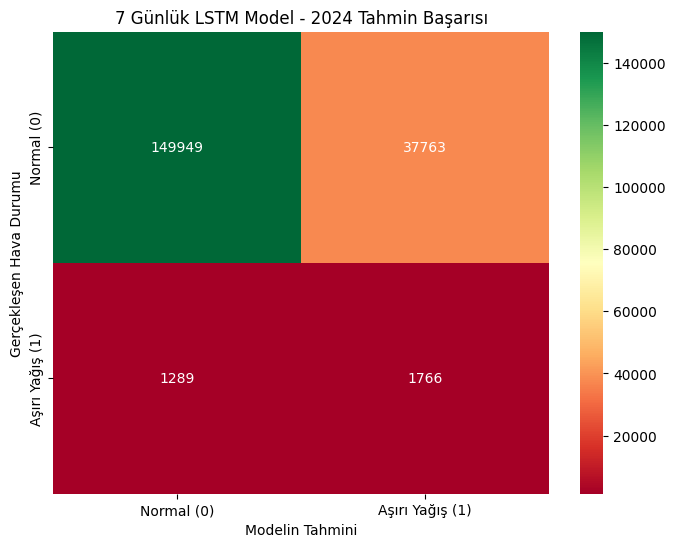

7 Günlük Modelin F1-Skoru: 0.0829

Model 'asiri_yagis_modeli_7gun.keras' adıyla kaydedildi. Artık dosyayı kapatsan da olur!


In [21]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_prob = model_7gun.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("--- 2024 YILI (TEST SETİ) NİHAİ BAŞARI RAPORU ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Normal (0)', 'Aşırı Yağış (1)'],
            yticklabels=['Normal (0)', 'Aşırı Yağış (1)'])
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçekleşen Hava Durumu')
plt.title('7 Günlük LSTM Model - 2024 Tahmin Başarısı')
plt.show()

f1_7gun = f1_score(y_test, y_pred)
print(f"7 Günlük Modelin F1-Skoru: {f1_7gun:.4f}")

model_7gun.save("asiri_yagis_modeli_7gun.keras")
print("\nModel 'asiri_yagis_modeli_7gun.keras' adıyla kaydedildi. Artık dosyayı kapatsan da olur!")

In [22]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

deney_gunleri = [3, 14]
sonuclar = {}

sonuclar[7] = 0.0830 

for gun in deney_gunleri:
    print(f"\n>>> {gun} GÜNLÜK PENCERE DENEYİ BAŞLIYOR <<<")
    
    X_train_d, y_train_d = pencere_olustur(train_scaled, train_df['Asiri_Yagis_Mi'], train_df['Kopru_Isim'], gun)
    X_test_d, y_test_d = pencere_olustur(test_scaled, test_df['Asiri_Yagis_Mi'], test_df['Kopru_Isim'], gun)
    
    weights_d = compute_class_weight('balanced', classes=np.unique(y_train_d), y=y_train_d)
    cw_dict = {0: weights_d[0], 1: weights_d[1]}
    
    model_d = Sequential([
        Input(shape=(X_train_d.shape[1], X_train_d.shape[2])),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model_d.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    model_d.fit(
        X_train_d, y_train_d,
        epochs=15, 
        batch_size=512, 
        validation_split=0.1,
        class_weight=cw_dict,
        callbacks=[early_stop],
        verbose=0 
    )
    
   
    y_pred_d = (model_d.predict(X_test_d) > 0.5).astype(int)
    f1 = f1_score(y_test_d, y_pred_d)
    sonuclar[gun] = f1
    
    print(f"--- {gun} Günlük Deney Tamamlandı | F1-Skoru: {f1:.4f} ---")

print("\n" + "="*40)
print("DENEY SONUÇLARI (LOOKBACK OPTİMİZASYONU)")
print("="*40)
for g, s in sorted(sonuclar.items()):
    yildiz = " <--- EN İYİ" if s == max(sonuclar.values()) else ""
    print(f"{g} Günlük Lookback: F1 = {s:.4f}{yildiz}")


>>> 3 GÜNLÜK PENCERE DENEYİ BAŞLIYOR <<<
5979/5979 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
--- 3 Günlük Deney Tamamlandı | F1-Skoru: 0.0934 ---

>>> 14 GÜNLÜK PENCERE DENEYİ BAŞLIYOR <<<
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
--- 14 Günlük Deney Tamamlandı | F1-Skoru: 0.0845 ---

DENEY SONUÇLARI (LOOKBACK OPTİMİZASYONU)
3 Günlük Lookback: F1 = 0.0934 <--- EN İYİ
7 Günlük Lookback: F1 = 0.0830
14 Günlük Lookback: F1 = 0.0845


In [23]:
lookback_3 = 3

X_train_3, y_train_3 = pencere_olustur(train_scaled, train_df['Asiri_Yagis_Mi'], train_df['Kopru_Isim'], lookback_3)
X_test_3, y_test_3 = pencere_olustur(test_scaled, test_df['Asiri_Yagis_Mi'], test_df['Kopru_Isim'], lookback_3)

weights_3 = compute_class_weight('balanced', classes=np.unique(y_train_3), y=y_train_3)
cw_3 = {0: weights_3[0], 1: weights_3[1]}

model_3 = Sequential([
    Input(shape=(X_train_3.shape[1], X_train_3.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_3.fit(X_train_3, y_train_3, epochs=10, batch_size=512, validation_split=0.1, class_weight=cw_3, verbose=1)

y_pred_prob_3 = model_3.predict(X_test_3)
y_pred = (y_pred_prob_3 > 0.5).astype(int)

test_results_3 = test_df.iloc[lookback_3:].copy()
test_results_3['Tahmin'] = y_pred

print("\n--- 3 GÜNLÜK MODEL ANALİZE HAZIR! ---")

Epoch 1/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6191 - loss: 0.6546 - val_accuracy: 0.5433 - val_loss: 0.6800
Epoch 2/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7355 - loss: 0.6027 - val_accuracy: 0.6618 - val_loss: 0.6240
Epoch 3/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7590 - loss: 0.5888 - val_accuracy: 0.8106 - val_loss: 0.5408
Epoch 4/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7580 - loss: 0.5834 - val_accuracy: 0.7641 - val_loss: 0.6025
Epoch 5/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7645 - loss: 0.5799 - val_accuracy: 0.8064 - val_loss: 0.5369
Epoch 6/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7592 - loss: 0.5757 - val_accuracy: 0.7706 - val_loss: 0.5613
Epoch 7/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7593 - loss: 0.5733 - val_accuracy: 0.6538 - val_loss: 0.6437
Epoch 8/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7625 - loss: 0

ValueError: Length of values (191327) does not match length of index (191744)

In [24]:
import pandas as pd

indices_to_keep = []
unique_stations = test_df['Kopru_Isim'].unique()

for st in unique_stations:
    st_indices = test_df[test_df['Kopru_Isim'] == st].index.tolist()
    if len(st_indices) > 3:
        indices_to_keep.extend(st_indices[3:])

test_results_3 = test_df.loc[indices_to_keep].copy()
test_results_3['Tahmin'] = y_pred.flatten()

def bolge_analizi(df):
    rapor = []
    for bolge in df['Iklim_Bolgesi'].unique():
        b_df = df[df['Iklim_Bolgesi'] == bolge]
        tp = ((b_df['Asiri_Yagis_Mi'] == 1) & (b_df['Tahmin'] == 1)).sum()
        fn = ((b_df['Asiri_Yagis_Mi'] == 1) & (b_df['Tahmin'] == 0)).sum()
        fp = ((b_df['Asiri_Yagis_Mi'] == 0) & (b_df['Tahmin'] == 1)).sum()
        
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        rapor.append({
            'Bölge': bolge,
            'Gerçek Ekstrem Olay': tp + fn,
            'Yakalama Oranı (Recall)': f"%{recall*100:.1f}",
            'Kesinlik (Precision)': f"%{precision*100:.1f}"
        })
    return pd.DataFrame(rapor)

bolge_raporu = bolge_analizi(test_results_3)
print("--- 3 GÜNLÜK MODEL: BÖLGE BAZLI BAŞARI ANALİZİ ---")
print(bolge_raporu.sort_values(by='Gerçek Ekstrem Olay', ascending=False).to_string(index=False))

--- 3 GÜNLÜK MODEL: BÖLGE BAZLI BAŞARI ANALİZİ ---
            Bölge  Gerçek Ekstrem Olay Yakalama Oranı (Recall) Kesinlik (Precision)
        Karadeniz                 1089                   %26.0                 %2.1
       Ic_Anadolu                  461                   %24.5                 %1.3
          Akdeniz                  422                   %21.3                 %1.4
     Dogu_Anadolu                  408                   %25.0                 %1.6
              Ege                  337                   %32.9                 %1.5
          Marmara                  246                   %26.0                 %1.6
Guneydogu_Anadolu                  110                   %24.5                 %1.1


In [25]:

false_positives = test_results_3[(test_results_3['Asiri_Yagis_Mi'] == 0) & (test_results_3['Tahmin'] == 1)].copy()

false_positives['Esik_Farki'] = false_positives['Bolge_Esigi_95'] - false_positives['Nihai_Yagis_mm']

toplam_fp = len(false_positives)
kil_payi_fp = len(false_positives[false_positives['Esik_Farki'] <= 5]) 

print("--- YANLIŞ ALARMLARIN (FP) KARAKTERİ ---")
print(f"Toplam Yanlış Alarm Sayısı: {toplam_fp}")
print(f"Eşiğe 5mm'den Daha Yakın Olan 'Kıl Payı' Yanlış Alarmlar: {kil_payi_fp}")
print(f"Kıl Payı Yanlış Alarmların Oranı: %{(kil_payi_fp / toplam_fp) * 100:.1f}")
print(f"Yanlış Alarmlardaki Ortalama Mesafe: {false_positives['Esik_Farki'].mean():.2f} mm")

--- YANLIŞ ALARMLARIN (FP) KARAKTERİ ---
Toplam Yanlış Alarm Sayısı: 48016
Eşiğe 5mm'den Daha Yakın Olan 'Kıl Payı' Yanlış Alarmlar: 543
Kıl Payı Yanlış Alarmların Oranı: %1.1
Yanlış Alarmlardaki Ortalama Mesafe: 20.39 mm


In [26]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X_train_flat = X_train_3[:, -1, :] 

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train_3)


importances = pd.DataFrame({
    'Özellik': ['Nihai_Yagis_mm', 'Ay_Sin', 'Ay_Cos', 'Gun_Sin', 'Gun_Cos'],
    'Önem Skoru': rf.feature_importances_
}).sort_values(by='Önem Skoru', ascending=False)

print("\n--- MODEL KARAR VERİRKEN NEYE BAKIYOR? (Feature Importance) ---")
print(importances.to_string(index=False))


--- MODEL KARAR VERİRKEN NEYE BAKIYOR? (Feature Importance) ---
       Özellik  Önem Skoru
Nihai_Yagis_mm    0.761120
       Gun_Cos    0.114369
       Gun_Sin    0.112513
        Ay_Sin    0.006060
        Ay_Cos    0.005938


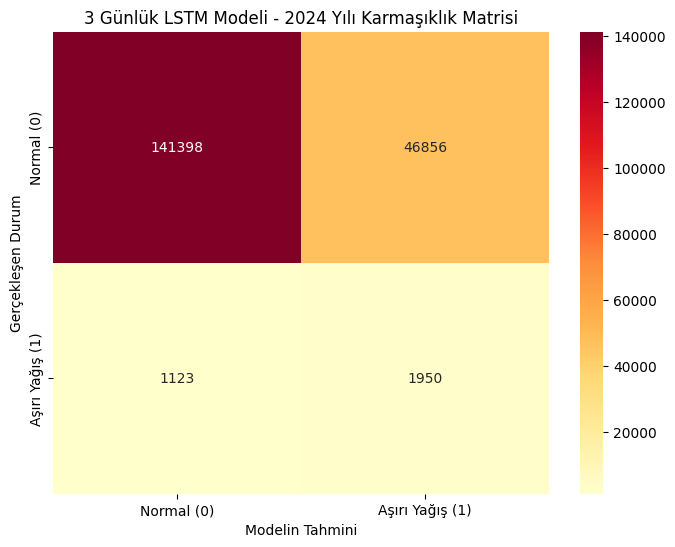


--- 3 GÜNLÜK MODEL NİHAİ PERFORMANS RAPORU ---
              precision    recall  f1-score   support

           0       0.99      0.75      0.85    188254
           1       0.04      0.63      0.08      3073

    accuracy                           0.75    191327
   macro avg       0.52      0.69      0.47    191327
weighted avg       0.98      0.75      0.84    191327



In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm_3 = confusion_matrix(y_test_3, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=['Normal (0)', 'Aşırı Yağış (1)'],
            yticklabels=['Normal (0)', 'Aşırı Yağış (1)'])

plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçekleşen Durum')
plt.title('3 Günlük LSTM Modeli - 2024 Yılı Karmaşıklık Matrisi')
plt.show()

print("\n--- 3 GÜNLÜK MODEL NİHAİ PERFORMANS RAPORU ---")
print(classification_report(y_test_3, y_pred))

--- KARAR EŞİĞİ (THRESHOLD) OPTİMİZASYONU ---
Varsayılan Eşik (0.5) ile F1: 0.0752
Bulunan Optimum Eşik: 0.8139
Optimum Eşik ile Beklenen F1: 0.1407


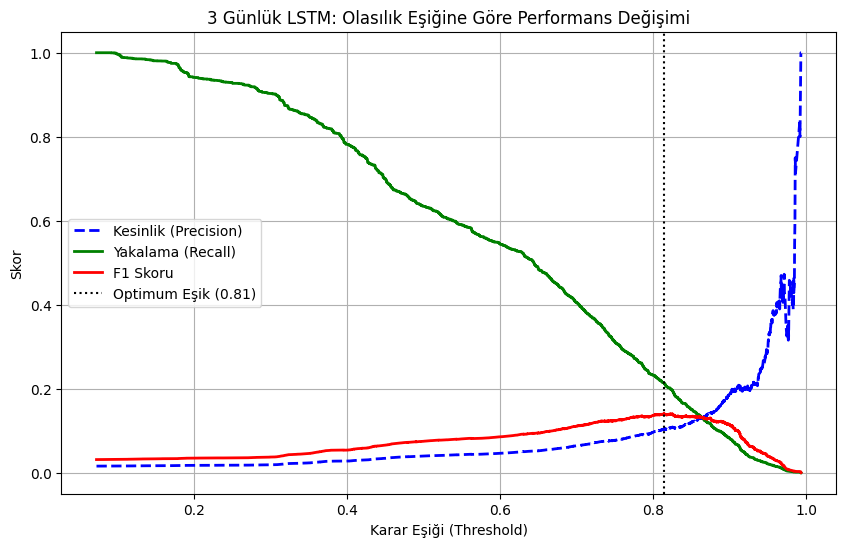


--- YENİ EŞİK DEĞERİNE GÖRE SONUÇLAR ---
Doğru Bilinen Aşırı Yağış (True Positive): 659
Kaçırılan Aşırı Yağış (False Negative): 2414
Yanlış Alarm (False Positive): 5649 (Eski hali 62 bindi!)


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix

precisions, recalls, thresholds = precision_recall_curve(y_test_3, y_pred_prob_3)


f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), 
                      out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print("--- KARAR EŞİĞİ (THRESHOLD) OPTİMİZASYONU ---")
print(f"Varsayılan Eşik (0.5) ile F1: {f1_score(y_test_3, (y_pred_prob_3 > 0.5).astype(int)):.4f}")
print(f"Bulunan Optimum Eşik: {optimal_threshold:.4f}")
print(f"Optimum Eşik ile Beklenen F1: {optimal_f1:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Kesinlik (Precision)', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Yakalama (Recall)', linewidth=2)
plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1 Skoru', linewidth=2)
plt.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Optimum Eşik ({optimal_threshold:.2f})')

plt.title('3 Günlük LSTM: Olasılık Eşiğine Göre Performans Değişimi')
plt.xlabel('Karar Eşiği (Threshold)')
plt.ylabel('Skor')
plt.legend(loc='best')
plt.grid(True)
plt.show()

y_pred_optimal = (y_pred_prob_3 > optimal_threshold).astype(int)
cm_optimal = confusion_matrix(y_test_3, y_pred_optimal)
print("\n--- YENİ EŞİK DEĞERİNE GÖRE SONUÇLAR ---")
print(f"Doğru Bilinen Aşırı Yağış (True Positive): {cm_optimal[1,1]}")
print(f"Kaçırılan Aşırı Yağış (False Negative): {cm_optimal[1,0]}")
print(f"Yanlış Alarm (False Positive): {cm_optimal[0,1]} (Eski hali 62 bindi!)")

In [29]:

print("Veriye bölgesel momentum (mekansal) özellikleri ekleniyor...")

train_df['Bolge_Gunluk_Ortalama'] = train_df.groupby(['Tarih', 'Iklim_Bolgesi'])['Nihai_Yagis_mm'].transform('mean')
train_df['Bolge_Gunluk_Max'] = train_df.groupby(['Tarih', 'Iklim_Bolgesi'])['Nihai_Yagis_mm'].transform('max')

test_df['Bolge_Gunluk_Ortalama'] = test_df.groupby(['Tarih', 'Iklim_Bolgesi'])['Nihai_Yagis_mm'].transform('mean')
test_df['Bolge_Gunluk_Max'] = test_df.groupby(['Tarih', 'Iklim_Bolgesi'])['Nihai_Yagis_mm'].transform('max')

print("\n--- YENİ EĞİTİM VERİSİ SÜTUNLARI ---")
print(train_df[['Tarih', 'Kopru_Isim', 'Iklim_Bolgesi', 'Nihai_Yagis_mm', 'Bolge_Gunluk_Ortalama', 'Bolge_Gunluk_Max']].head())

print("\nÖzellik Mühendisliği Tamamlandı! Verimiz artık 2 boyutlu analiz için zenginleştirildi.")

Veriye bölgesel momentum (mekansal) özellikleri ekleniyor...

--- YENİ EĞİTİM VERİSİ SÜTUNLARI ---
       Tarih Kopru_Isim Iklim_Bolgesi  Nihai_Yagis_mm  Bolge_Gunluk_Ortalama  \
0 2020-01-01   AK?AKOCA     Karadeniz             7.1               3.627559   
1 2020-01-02   AK?AKOCA     Karadeniz            26.5               6.947200   
2 2020-01-03   AK?AKOCA     Karadeniz             0.0               1.889516   
3 2020-01-04   AK?AKOCA     Karadeniz             0.0               2.067200   
4 2020-01-05   AK?AKOCA     Karadeniz             0.0               0.977049   

   Bolge_Gunluk_Max  
0              38.7  
1              30.2  
2              11.0  
3              14.3  
4              16.7  

Özellik Mühendisliği Tamamlandı! Verimiz artık 2 boyutlu analiz için zenginleştirildi.


In [30]:
from sklearn.preprocessing import MinMaxScaler

print("Yeni veriler ölçeklendiriliyor ve 3 günlük pencereler oluşturuluyor...")

yeni_ozellikler = ['Nihai_Yagis_mm', 'Ay_Sin', 'Ay_Cos', 'Gun_Sin', 'Gun_Cos', 
                   'Bolge_Gunluk_Ortalama', 'Bolge_Gunluk_Max']

scaler_cnn = MinMaxScaler()
train_scaled_cnn = scaler_cnn.fit_transform(train_df[yeni_ozellikler])
test_scaled_cnn = scaler_cnn.transform(test_df[yeni_ozellikler])


lookback_cnn = 3
X_train_cnn, y_train_cnn = pencere_olustur(train_scaled_cnn, train_df['Asiri_Yagis_Mi'], train_df['Kopru_Isim'], lookback_cnn)
X_test_cnn, y_test_cnn = pencere_olustur(test_scaled_cnn, test_df['Asiri_Yagis_Mi'], test_df['Kopru_Isim'], lookback_cnn)

print("\n--- CNN-LSTM İÇİN VERİ HAZIRLIĞI TAMAM! ---")
print(f"Eski Eğitim Verisi Şekli: {X_train_3.shape} (5 Özellik)")
print(f"Yeni Eğitim Verisi Şekli: {X_train_cnn.shape} (7 Özellik - Mekansal Veri Eklendi)")

Yeni veriler ölçeklendiriliyor ve 3 günlük pencereler oluşturuluyor...

--- CNN-LSTM İÇİN VERİ HAZIRLIĞI TAMAM! ---
Eski Eğitim Verisi Şekli: (725893, 3, 5) (5 Özellik)
Yeni Eğitim Verisi Şekli: (725893, 3, 7) (7 Özellik - Mekansal Veri Eklendi)


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print("CNN-LSTM Mimarisi Kuruluyor...")

weights_cnn = compute_class_weight('balanced', classes=np.unique(y_train_cnn), y=y_train_cnn)
cw_cnn = {0: weights_cnn[0], 1: weights_cnn[1]}

model_cnn = Sequential([
    Input(shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])),
    
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='valid'),
    
    LSTM(32, return_sequences=False),
    Dropout(0.2), 
    
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') 
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- CNN-LSTM EĞİTİMİ BAŞLIYOR (10 EPOCH) ---")
history_cnn = model_cnn.fit(X_train_cnn, y_train_cnn, epochs=10, batch_size=512, 
                            validation_split=0.1, class_weight=cw_cnn, verbose=1)

y_pred_prob_cnn = model_cnn.predict(X_test_cnn)
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int).flatten()

cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
print("\n--- CNN-LSTM NİHAİ SONUÇLARI (0.5 EŞİĞİ) ---")
print(f"Doğru Bilinen Aşırı Yağış (TP): {cm_cnn[1,1]} (Eski LSTM: 2203)")
print(f"Yanlış Alarm Sayısı (FP): {cm_cnn[0,1]} (Eski LSTM: 62.616)")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test_cnn, y_pred_cnn))

CNN-LSTM Mimarisi Kuruluyor...

--- CNN-LSTM EĞİTİMİ BAŞLIYOR (10 EPOCH) ---
Epoch 1/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6793 - loss: 0.5930 - val_accuracy: 0.7017 - val_loss: 0.5746
Epoch 2/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7002 - loss: 0.5589 - val_accuracy: 0.7201 - val_loss: 0.5149
Epoch 3/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7058 - loss: 0.5491 - val_accuracy: 0.7069 - val_loss: 0.5298
Epoch 4/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7059 - loss: 0.5437 - val_accuracy: 0.7305 - val_loss: 0.4921
Epoch 5/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7063 - loss: 0.5393 - val_accuracy: 0.7177 - val_loss: 0.5004
Epoch 6/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7011 - loss: 0.5344 - val_accuracy: 0.7183 - val_loss: 0.5025
Epoch 7/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7022 - loss: 0.5327 - val_accuracy: 0.7169 - val_loss: 0.5552
Epoch 8/10
12

CNN-LSTM için Optimum Karar Eşiği Hesaplanıyor...

--- CNN-LSTM OPTİMUM EŞİK (THRESHOLD) SONUÇLARI ---
Bulunan Optimum Eşik: 0.8143
Optimum Eşik ile Beklenen F1: 0.1483
----------------------------------------
Doğru Bilinen Aşırı Yağış (TP): 576 (Eski LSTM Optimum TP: 458)
Kaçırılan Aşırı Yağış (FN): 2497
Yanlış Alarm (FP): 4194 (Eski LSTM Optimum FP: 3167)


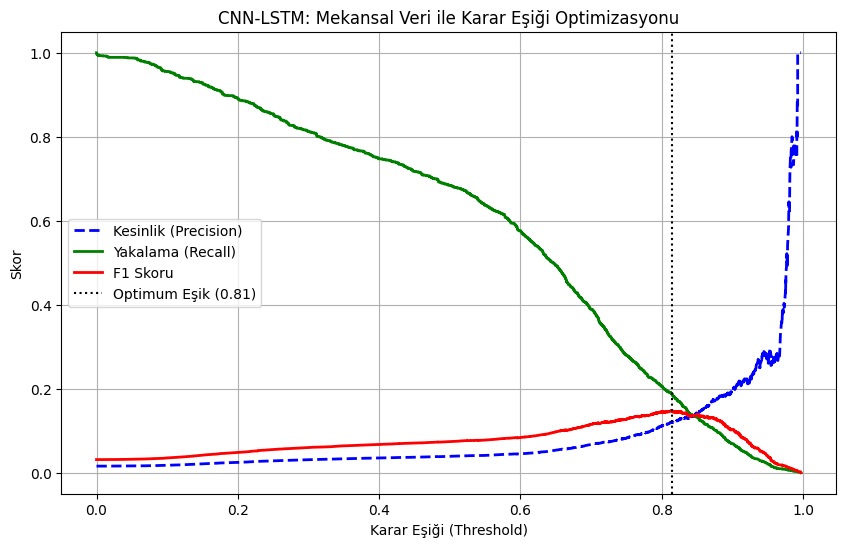

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix

print("CNN-LSTM için Optimum Karar Eşiği Hesaplanıyor...")

precisions_cnn, recalls_cnn, thresholds_cnn = precision_recall_curve(y_test_cnn, y_pred_prob_cnn)

f1_scores_cnn = np.divide(2 * (precisions_cnn * recalls_cnn), (precisions_cnn + recalls_cnn), 
                          out=np.zeros_like(precisions_cnn), where=(precisions_cnn + recalls_cnn) != 0)

optimal_idx_cnn = np.argmax(f1_scores_cnn)
optimal_threshold_cnn = thresholds_cnn[optimal_idx_cnn]
optimal_f1_cnn = f1_scores_cnn[optimal_idx_cnn]

y_pred_optimal_cnn = (y_pred_prob_cnn > optimal_threshold_cnn).astype(int)
cm_optimal_cnn = confusion_matrix(y_test_cnn, y_pred_optimal_cnn)

print("\n--- CNN-LSTM OPTİMUM EŞİK (THRESHOLD) SONUÇLARI ---")
print(f"Bulunan Optimum Eşik: {optimal_threshold_cnn:.4f}")
print(f"Optimum Eşik ile Beklenen F1: {optimal_f1_cnn:.4f}")
print("-" * 40)
print(f"Doğru Bilinen Aşırı Yağış (TP): {cm_optimal_cnn[1,1]} (Eski LSTM Optimum TP: 458)")
print(f"Kaçırılan Aşırı Yağış (FN): {cm_optimal_cnn[1,0]}")
print(f"Yanlış Alarm (FP): {cm_optimal_cnn[0,1]} (Eski LSTM Optimum FP: 3167)")

plt.figure(figsize=(10, 6))
plt.plot(thresholds_cnn, precisions_cnn[:-1], 'b--', label='Kesinlik (Precision)', linewidth=2)
plt.plot(thresholds_cnn, recalls_cnn[:-1], 'g-', label='Yakalama (Recall)', linewidth=2)
plt.plot(thresholds_cnn, f1_scores_cnn[:-1], 'r-', label='F1 Skoru', linewidth=2)
plt.axvline(x=optimal_threshold_cnn, color='k', linestyle=':', label=f'Optimum Eşik ({optimal_threshold_cnn:.2f})')

plt.title('CNN-LSTM: Mekansal Veri ile Karar Eşiği Optimizasyonu')
plt.xlabel('Karar Eşiği (Threshold)')
plt.ylabel('Skor')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_optimal_cnn = (y_pred_prob_cnn > optimal_threshold_cnn).astype(int)

print(f"=== CNN-LSTM OPTİMUM EŞİK ({optimal_threshold_cnn:.4f}) PERFORMANS RAPORU ===\n")

cm_optimal = confusion_matrix(y_test_cnn, y_pred_optimal_cnn)
print("--- 1. KARMAŞIKLIK MATRİSİ ÖZETİ ---")
print(f"Doğru Bilinen Normal Günler (True Negative) : {cm_optimal[0,0]}")
print(f"Yanlış Alarm (False Positive)               : {cm_optimal[0,1]}")
print(f"Kaçırılan Aşırı Yağış (False Negative)      : {cm_optimal[1,0]}")
print(f"Doğru Bilinen Aşırı Yağış (True Positive)   : {cm_optimal[1,1]}\n")

print("--- 2. SINIFLANDIRMA RAPORU ---")
rapor = classification_report(
    y_test_cnn, 
    y_pred_optimal_cnn, 
    target_names=['Normal Gün (0)', 'Aşırı Yağış (1)']
)
print(rapor)

=== CNN-LSTM OPTİMUM EŞİK (0.8143) PERFORMANS RAPORU ===

--- 1. KARMAŞIKLIK MATRİSİ ÖZETİ ---
Doğru Bilinen Normal Günler (True Negative) : 184060
Yanlış Alarm (False Positive)               : 4194
Kaçırılan Aşırı Yağış (False Negative)      : 2497
Doğru Bilinen Aşırı Yağış (True Positive)   : 576

--- 2. SINIFLANDIRMA RAPORU ---
                 precision    recall  f1-score   support

 Normal Gün (0)       0.99      0.98      0.98    188254
Aşırı Yağış (1)       0.12      0.19      0.15      3073

       accuracy                           0.97    191327
      macro avg       0.55      0.58      0.56    191327
   weighted avg       0.97      0.97      0.97    191327



In [34]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
print("Kütüphane başarıyla çekirdeğe enjekte edildi. SMOTE kodunu artık çalıştırabilirsin!")

Kütüphane başarıyla çekirdeğe enjekte edildi. SMOTE kodunu artık çalıştırabilirsin!


In [35]:
from imblearn.over_sampling import SMOTE
import numpy as np

print("--- SMOTE İŞLEMİ BAŞLIYOR ---")
print(f"SMOTE Öncesi Eğitim Verisi Şekli: {X_train_cnn.shape}")
print(f"SMOTE Öncesi Sınıf Dağılımı: 0 (Normal) = {sum(y_train_cnn == 0)}, 1 (Aşırı) = {sum(y_train_cnn == 1)}")

ornek_sayisi = X_train_cnn.shape[0]
zaman_adimi = X_train_cnn.shape[1]
ozellik_sayisi = X_train_cnn.shape[2]

X_train_flat = X_train_cnn.reshape(ornek_sayisi, zaman_adimi * ozellik_sayisi)

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_resampled_flat, y_train_resampled = smote.fit_resample(X_train_flat, y_train_cnn)

X_train_resampled = X_train_resampled_flat.reshape(X_train_resampled_flat.shape[0], zaman_adimi, ozellik_sayisi)

print("\n--- SMOTE İŞLEMİ TAMAMLANDI! ---")
print(f"SMOTE Sonrası YENİ Eğitim Verisi Şekli: {X_train_resampled.shape}")
print(f"SMOTE Sonrası YENİ Sınıf Dağılımı: 0 (Normal) = {sum(y_train_resampled == 0)}, 1 (Aşırı) = {sum(y_train_resampled == 1)}")

--- SMOTE İŞLEMİ BAŞLIYOR ---
SMOTE Öncesi Eğitim Verisi Şekli: (725893, 3, 7)
SMOTE Öncesi Sınıf Dağılımı: 0 (Normal) = 714040, 1 (Aşırı) = 11853

--- SMOTE İŞLEMİ TAMAMLANDI! ---
SMOTE Sonrası YENİ Eğitim Verisi Şekli: (1428080, 3, 7)
SMOTE Sonrası YENİ Sınıf Dağılımı: 0 (Normal) = 714040, 1 (Aşırı) = 714040


--- SMOTE ORANI OPTİMİZASYON TESTİ BAŞLIYOR ---
Not: 5 farklı oran denenecek. Hızlı sonuç için sadece 3'er epoch eğitilecektir.


>> 0.2 Oranı İçin Test Başlıyor...
Oran 0.2 -> Beklenen Recall: 0.1900 | Beklenen F1: 0.1395

>> 0.4 Oranı İçin Test Başlıyor...
Oran 0.4 -> Beklenen Recall: 0.3508 | Beklenen F1: 0.1115

>> 0.6 Oranı İçin Test Başlıyor...
Oran 0.6 -> Beklenen Recall: 0.6352 | Beklenen F1: 0.0841

>> 0.8 Oranı İçin Test Başlıyor...
Oran 0.8 -> Beklenen Recall: 0.6720 | Beklenen F1: 0.0786

>> 1.0 Oranı İçin Test Başlıyor...
Oran 1.0 -> Beklenen Recall: 0.7081 | Beklenen F1: 0.0751


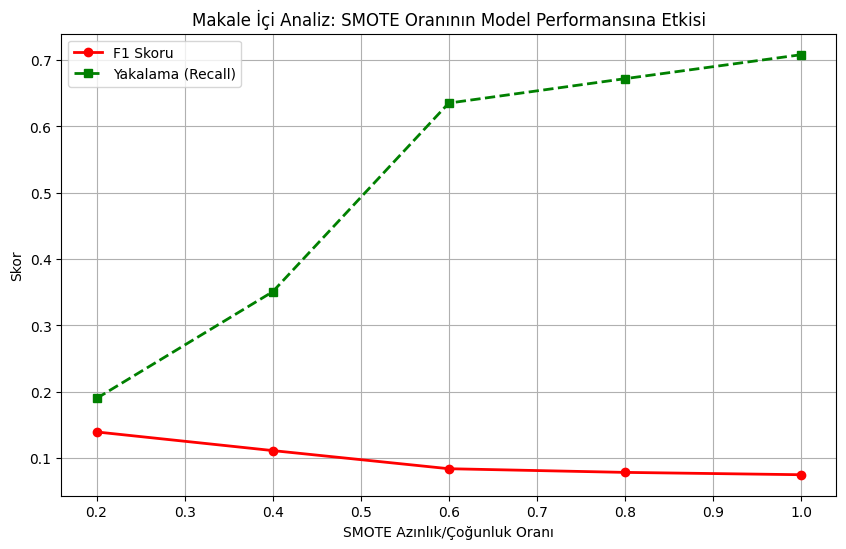


--- TEST BİTTİ! Grafiğe ve çıktılara bakarak en mantıklı oranı seçebiliriz. ---


In [36]:
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout
from sklearn.metrics import f1_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

print("--- SMOTE ORANI OPTİMİZASYON TESTİ BAŞLIYOR ---")
print("Not: 5 farklı oran denenecek. Hızlı sonuç için sadece 3'er epoch eğitilecektir.\n")


smote_oranlari = [0.2, 0.4, 0.6, 0.8, 1.0]

f1_sonuclari = []
recall_sonuclari = []

ornek_sayisi = X_train_cnn.shape[0]
zaman_adimi = X_train_cnn.shape[1]
ozellik_sayisi = X_train_cnn.shape[2]
X_train_flat = X_train_cnn.reshape(ornek_sayisi, zaman_adimi * ozellik_sayisi)

for oran in smote_oranlari:
    print(f"\n>> {oran} Oranı İçin Test Başlıyor...")
    
    smote = SMOTE(sampling_strategy=oran, random_state=42)
    X_res_flat, y_res = smote.fit_resample(X_train_flat, y_train_cnn)
    X_res = X_res_flat.reshape(X_res_flat.shape[0], zaman_adimi, ozellik_sayisi)
    
    model_test = Sequential([
        Input(shape=(X_res.shape[1], X_res.shape[2])),
        Conv1D(filters=64, kernel_size=2, activation='relu', padding='valid'),
        LSTM(32, return_sequences=False),
        Dropout(0.2), 
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid') 
    ])
    model_test.compile(optimizer='adam', loss='binary_crossentropy')
    
    model_test.fit(X_res, y_res, epochs=3, batch_size=2048, verbose=0)
    
    y_pred_prob = model_test.predict(X_test_cnn, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    f1 = f1_score(y_test_cnn, y_pred)
    recall = recall_score(y_test_cnn, y_pred)
    
    f1_sonuclari.append(f1)
    recall_sonuclari.append(recall)
    
    print(f"Oran {oran} -> Beklenen Recall: {recall:.4f} | Beklenen F1: {f1:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(smote_oranlari, f1_sonuclari, marker='o', linestyle='-', color='r', label='F1 Skoru', linewidth=2)
plt.plot(smote_oranlari, recall_sonuclari, marker='s', linestyle='--', color='g', label='Yakalama (Recall)', linewidth=2)

plt.title('Makale İçi Analiz: SMOTE Oranının Model Performansına Etkisi')
plt.xlabel('SMOTE Azınlık/Çoğunluk Oranı')
plt.ylabel('Skor')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print("\n--- TEST BİTTİ! Grafiğe ve çıktılara bakarak en mantıklı oranı seçebiliriz. ---")

In [37]:
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout
from sklearn.metrics import precision_recall_curve, confusion_matrix
import numpy as np

print("--- 0.4 ORANI İÇİN GERÇEK (10 EPOCH) EĞİTİM BAŞLIYOR ---")
smote_04 = SMOTE(sampling_strategy=0.4, random_state=42)
X_res_flat_04, y_res_04 = smote_04.fit_resample(X_train_flat, y_train_cnn)
X_res_04 = X_res_flat_04.reshape(X_res_flat_04.shape[0], zaman_adimi, ozellik_sayisi)

model_04 = Sequential([
    Input(shape=(X_res_04.shape[1], X_res_04.shape[2])),
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='valid'),
    LSTM(32, return_sequences=False),
    Dropout(0.2), 
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') 
])
model_04.compile(optimizer='adam', loss='binary_crossentropy')

model_04.fit(X_res_04, y_res_04, epochs=10, batch_size=2048, validation_split=0.1, verbose=1)

print("\nEğitim Bitti! 0.4 Oranı için Optimum Eşik ve Sonuçlar Hesaplanıyor...")
y_pred_prob_04 = model_04.predict(X_test_cnn)
precisions_04, recalls_04, thresholds_04 = precision_recall_curve(y_test_cnn, y_pred_prob_04)
f1_scores_04 = np.divide(2 * (precisions_04 * recalls_04), (precisions_04 + recalls_04), 
                         out=np.zeros_like(precisions_04), where=(precisions_04 + recalls_04) != 0)

opt_thresh_04 = thresholds_04[np.argmax(f1_scores_04)]
y_pred_opt_04 = (y_pred_prob_04 > opt_thresh_04).astype(int)
cm_04 = confusion_matrix(y_test_cnn, y_pred_opt_04)

print(f"\n=== 0.4 ORANI NİHAİ SONUÇ (Optimum Eşik: {opt_thresh_04:.4f}) ===")
print(f"Toplam Gerçekleşen Aşırı Yağış: 3073")
print("-" * 40)
print(f"Doğru Bilinen (TP): {cm_04[1,1]}")
print(f"Kaçırılan (FN): {cm_04[1,0]}")
print(f"Yanlış Alarm (FP): {cm_04[0,1]}")

--- 0.4 ORANI İÇİN GERÇEK (10 EPOCH) EĞİTİM BAŞLIYOR ---
Epoch 1/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.4693 - val_loss: 1.3039
Epoch 2/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4143 - val_loss: 1.1385
Epoch 3/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4030 - val_loss: 1.1929
Epoch 4/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3983 - val_loss: 1.0771
Epoch 5/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3951 - val_loss: 1.1829
Epoch 6/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3933 - val_loss: 1.1115
Epoch 7/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3905 - val_loss: 1.1368
Epoch 8/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3879 - val_loss: 1.0600
Epoch 9/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3854 - val_loss: 1.0609
Epoch 10/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3837 - val_loss: 1.0618

Eğitim Bitti! 0.4 Oranı için Optimum Eşik ve Sonuçlar Hesaplanıyor...
5979/5979 ━

In [38]:
print("\n--- 0.6 ORANI İÇİN GERÇEK (10 EPOCH) EĞİTİM BAŞLIYOR ---")
smote_06 = SMOTE(sampling_strategy=0.6, random_state=42)
X_res_flat_06, y_res_06 = smote_06.fit_resample(X_train_flat, y_train_cnn)
X_res_06 = X_res_flat_06.reshape(X_res_flat_06.shape[0], zaman_adimi, ozellik_sayisi)

model_06 = Sequential([
    Input(shape=(X_res_06.shape[1], X_res_06.shape[2])),
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='valid'),
    LSTM(32, return_sequences=False),
    Dropout(0.2), 
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') 
])
model_06.compile(optimizer='adam', loss='binary_crossentropy')

model_06.fit(X_res_06, y_res_06, epochs=10, batch_size=2048, validation_split=0.1, verbose=1)

print("\nEğitim Bitti! 0.6 Oranı için Optimum Eşik ve Sonuçlar Hesaplanıyor...")
y_pred_prob_06 = model_06.predict(X_test_cnn)
precisions_06, recalls_06, thresholds_06 = precision_recall_curve(y_test_cnn, y_pred_prob_06)
f1_scores_06 = np.divide(2 * (precisions_06 * recalls_06), (precisions_06 + recalls_06), 
                         out=np.zeros_like(precisions_06), where=(precisions_06 + recalls_06) != 0)

opt_thresh_06 = thresholds_06[np.argmax(f1_scores_06)]
y_pred_opt_06 = (y_pred_prob_06 > opt_thresh_06).astype(int)
cm_06 = confusion_matrix(y_test_cnn, y_pred_opt_06)

print(f"\n=== 0.6 ORANI NİHAİ SONUÇ (Optimum Eşik: {opt_thresh_06:.4f}) ===")
print(f"Toplam Gerçekleşen Aşırı Yağış: 3073")
print("-" * 40)
print(f"Doğru Bilinen (TP): {cm_06[1,1]}")
print(f"Kaçırılan (FN): {cm_06[1,0]}")
print(f"Yanlış Alarm (FP): {cm_06[0,1]}")


--- 0.6 ORANI İÇİN GERÇEK (10 EPOCH) EĞİTİM BAŞLIYOR ---
Epoch 1/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.5309 - val_loss: 0.7867
Epoch 2/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4846 - val_loss: 0.8824
Epoch 3/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4732 - val_loss: 0.8261
Epoch 4/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.4659 - val_loss: 0.8355
Epoch 5/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4596 - val_loss: 0.8010
Epoch 6/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4555 - val_loss: 0.8423
Epoch 7/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4520 - val_loss: 0.8817
Epoch 8/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4496 - val_loss: 0.9314
Epoch 9/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4468 - val_loss: 0.7531
Epoch 10/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4457 - val_loss: 0.8021

Eğitim Bitti! 0.6 Oranı için Optimum Eşik ve Sonuçlar Hesaplanıyor...
5979/5979 

In [39]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout
from sklearn.metrics import precision_recall_curve, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

print("--- 30 GÜNLÜK PENCERELER OLUŞTURULUYOR ---")
lookback_30 = 30

X_train_30, y_train_30 = pencere_olustur(train_scaled_cnn, train_df['Asiri_Yagis_Mi'], train_df['Kopru_Isim'], lookback_30)
X_test_30, y_test_30 = pencere_olustur(test_scaled_cnn, test_df['Asiri_Yagis_Mi'], test_df['Kopru_Isim'], lookback_30)

print(f"Yeni Eğitim Verisi Şekli: {X_train_30.shape}")

weights_30 = compute_class_weight('balanced', classes=np.unique(y_train_30), y=y_train_30)
cw_30 = {0: weights_30[0], 1: weights_30[1]}

print("\n--- 30 GÜNLÜK CNN-LSTM EĞİTİMİ BAŞLIYOR (10 EPOCH) ---")
model_30 = Sequential([
    Input(shape=(X_train_30.shape[1], X_train_30.shape[2])),
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='valid'),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_30.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_30.fit(X_train_30, y_train_30, epochs=10, batch_size=512, 
             validation_split=0.1, class_weight=cw_30, verbose=1)

print("\nEğitim bitti. Optimum Eşik Hesaplanıyor...")
y_pred_prob_30 = model_30.predict(X_test_30)

precisions_30, recalls_30, thresholds_30 = precision_recall_curve(y_test_30, y_pred_prob_30)
f1_scores_30 = np.divide(2 * (precisions_30 * recalls_30), (precisions_30 + recalls_30), 
                         out=np.zeros_like(precisions_30), where=(precisions_30 + recalls_30) != 0)

opt_idx_30 = np.argmax(f1_scores_30)
opt_thresh_30 = thresholds_30[opt_idx_30]
y_pred_opt_30 = (y_pred_prob_30 > opt_thresh_30).astype(int)

cm_30 = confusion_matrix(y_test_30, y_pred_opt_30)

print(f"\n=== 30 GÜNLÜK MODEL NİHAİ SONUÇLARI (Optimum Eşik: {opt_thresh_30:.4f}) ===")
print("--- KARMAŞIKLIK MATRİSİ ÖZETİ ---")
print(f"Doğru Bilinen Normal Günler (TN) : {cm_30[0,0]}")
print(f"Yanlış Alarm (FP)                : {cm_30[0,1]}")
print(f"Kaçırılan Aşırı Yağış (FN)       : {cm_30[1,0]}")
print(f"Doğru Bilinen Aşırı Yağış (TP)   : {cm_30[1,1]}\n")

--- 30 GÜNLÜK PENCERELER OLUŞTURULUYOR ---
Yeni Eğitim Verisi Şekli: (722113, 30, 7)

--- 30 GÜNLÜK CNN-LSTM EĞİTİMİ BAŞLIYOR (10 EPOCH) ---
Epoch 1/10
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.6576 - loss: 0.5965 - val_accuracy: 0.7734 - val_loss: 0.4889
Epoch 2/10
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 34s 26ms/step - accuracy: 0.7077 - loss: 0.5449 - val_accuracy: 0.6446 - val_loss: 0.6146
Epoch 3/10
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.7003 - loss: 0.5264 - val_accuracy: 0.7401 - val_loss: 0.4692
Epoch 4/10
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.7078 - loss: 0.5169 - val_accuracy: 0.7066 - val_loss: 0.5159
Epoch 5/10
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.7126 - loss: 0.5081 - val_accuracy: 0.6885 - val_loss: 0.5330
Epoch 6/10
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.7131 - loss: 0.5014 - val_accuracy: 0.7306 - val_loss: 0.4736
Epoch 7/10
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy:

C:\Users\Berke Güngörmez\AppData\Local\Temp\ipykernel_31704\446114686.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bolge_istatistik = yagisli_df.groupby('Iklim_Bolgesi').apply(
C:\Users\Berke Güngörmez\AppData\Local\Temp\ipykernel_31704\446114686.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


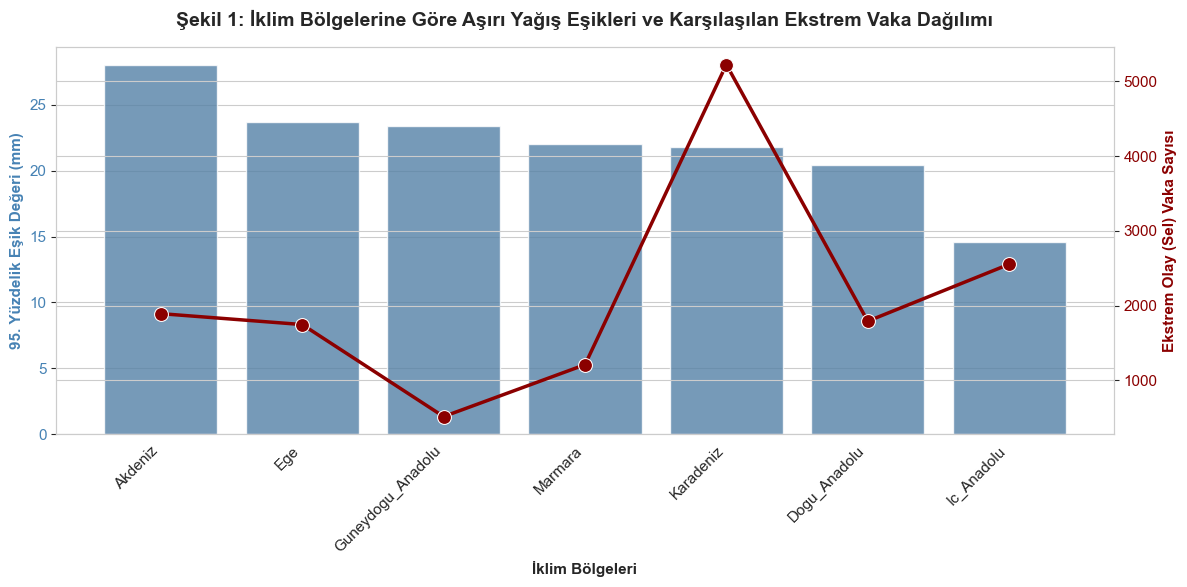

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})

yagisli_df = birlestirilmis_df[birlestirilmis_df['Nihai_Yagis_mm'] > 0]
bolge_istatistik = yagisli_df.groupby('Iklim_Bolgesi').apply(
    lambda x: pd.Series({
        'Esik_95': np.percentile(x['Nihai_Yagis_mm'], 95),
        'Ekstrem_Vaka_Sayisi': (x['Nihai_Yagis_mm'] >= np.percentile(x['Nihai_Yagis_mm'], 95)).sum()
    })
).reset_index()

bolge_istatistik = bolge_istatistik.sort_values(by='Esik_95', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x='Iklim_Bolgesi', y='Esik_95', data=bolge_istatistik, color='steelblue', ax=ax1, alpha=0.8)
ax1.set_xlabel('İklim Bölgeleri', fontweight='bold')
ax1.set_ylabel('95. Yüzdelik Eşik Değeri (mm)', fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()  
sns.lineplot(x='Iklim_Bolgesi', y='Ekstrem_Vaka_Sayisi', data=bolge_istatistik, 
             color='darkred', marker='o', markersize=10, linewidth=2.5, ax=ax2)
ax2.set_ylabel('Ekstrem Olay (Sel) Vaka Sayısı', fontweight='bold', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title('Şekil 1: İklim Bölgelerine Göre Aşırı Yağış Eşikleri ve Karşılaşılan Ekstrem Vaka Dağılımı', 
          fontweight='bold', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

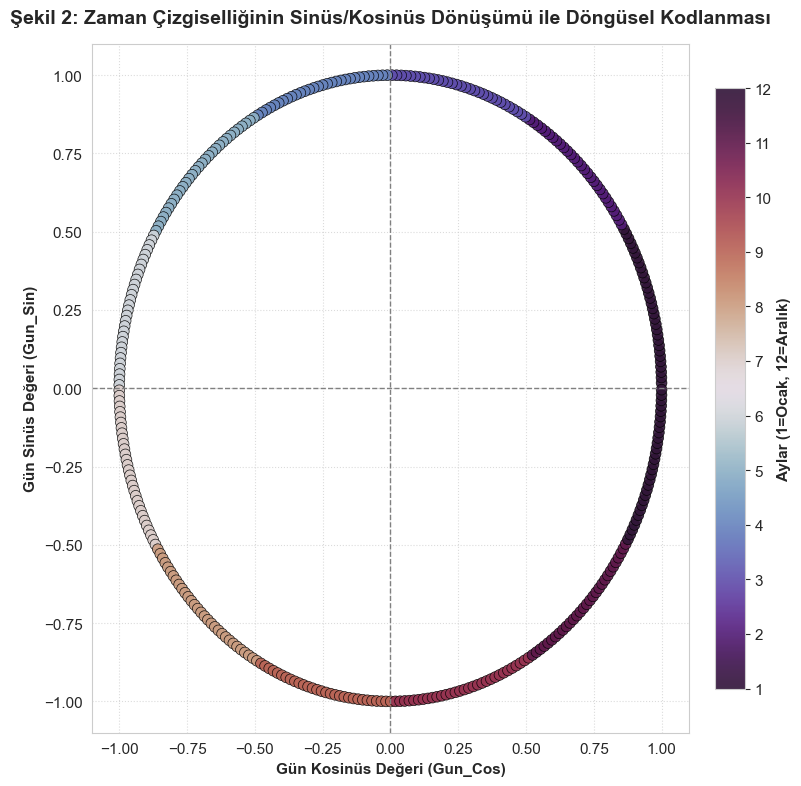

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


ornek_zaman_df = birlestirilmis_df.head(365).copy()

plt.figure(figsize=(8, 8))

scatter = plt.scatter(ornek_zaman_df['Gun_Cos'], ornek_zaman_df['Gun_Sin'], 
                      c=ornek_zaman_df['AY'], cmap='twilight_shifted', 
                      alpha=0.9, s=60, edgecolor='k', linewidth=0.5)

cbar = plt.colorbar(scatter, ticks=range(1, 13), fraction=0.046, pad=0.04)
cbar.set_label('Aylar (1=Ocak, 12=Aralık)', fontweight='bold')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

plt.title('Şekil 2: Zaman Çizgiselliğinin Sinüs/Kosinüs Dönüşümü ile Döngüsel Kodlanması', 
          fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Gün Kosinüs Değeri (Gun_Cos)', fontweight='bold')
plt.ylabel('Gün Sinüs Değeri (Gun_Sin)', fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\Berke Güngörmez\AppData\Local\Temp\ipykernel_31704\3756915376.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Önem Skoru', y='Özellik', data=importances_df, palette='viridis')


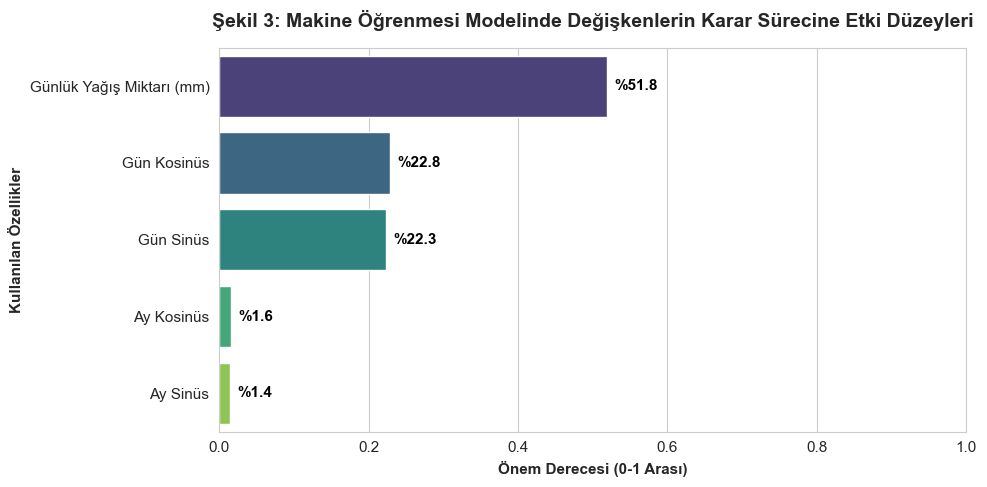

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier


X_train_flat_sample = X_train_3[:10000, -1, :] 
y_train_sample = y_train_3[:10000]

rf_viz = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_viz.fit(X_train_flat_sample, y_train_sample)

ozellik_isimleri = ['Günlük Yağış Miktarı (mm)', 'Ay Sinüs', 'Ay Kosinüs', 'Gün Sinüs', 'Gün Kosinüs']

importances_df = pd.DataFrame({
    'Özellik': ozellik_isimleri,
    'Önem Skoru': rf_viz.feature_importances_
}).sort_values(by='Önem Skoru', ascending=False)

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

ax = sns.barplot(x='Önem Skoru', y='Özellik', data=importances_df, palette='viridis')

for i, v in enumerate(importances_df['Önem Skoru']):
    ax.text(v + 0.01, i, f"%{v*100:.1f}", color='black', va='center', fontweight='bold')

plt.title('Şekil 3: Makine Öğrenmesi Modelinde Değişkenlerin Karar Sürecine Etki Düzeyleri', 
          fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Önem Derecesi (0-1 Arası)', fontweight='bold')
plt.ylabel('Kullanılan Özellikler', fontweight='bold')

plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

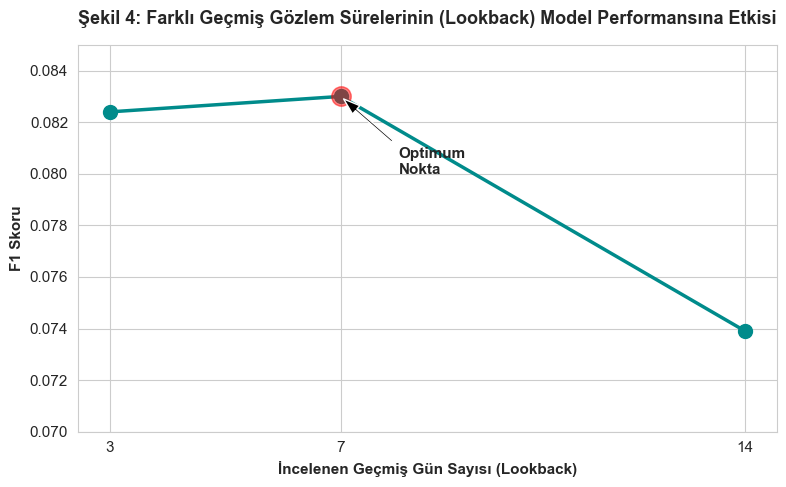

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns


lookback_gunleri = [3, 7, 14]
f1_skorlari = [0.0824, 0.0830, 0.0739]

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

plt.plot(lookback_gunleri, f1_skorlari, marker='o', markersize=10, 
         linestyle='-', linewidth=2.5, color='darkcyan')

plt.plot(7, 0.0830, marker='o', markersize=14, color='red', alpha=0.5)
plt.annotate('Optimum\nNokta', xy=(7, 0.0830), xytext=(8, 0.080),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold')

plt.title('Şekil 4: Farklı Geçmiş Gözlem Sürelerinin (Lookback) Model Performansına Etkisi', 
          fontweight='bold', fontsize=13, pad=15)
plt.xlabel('İncelenen Geçmiş Gün Sayısı (Lookback)', fontweight='bold')
plt.ylabel('F1 Skoru', fontweight='bold')
plt.xticks(lookback_gunleri)
plt.ylim(0.070, 0.085)

plt.tight_layout()
plt.show()

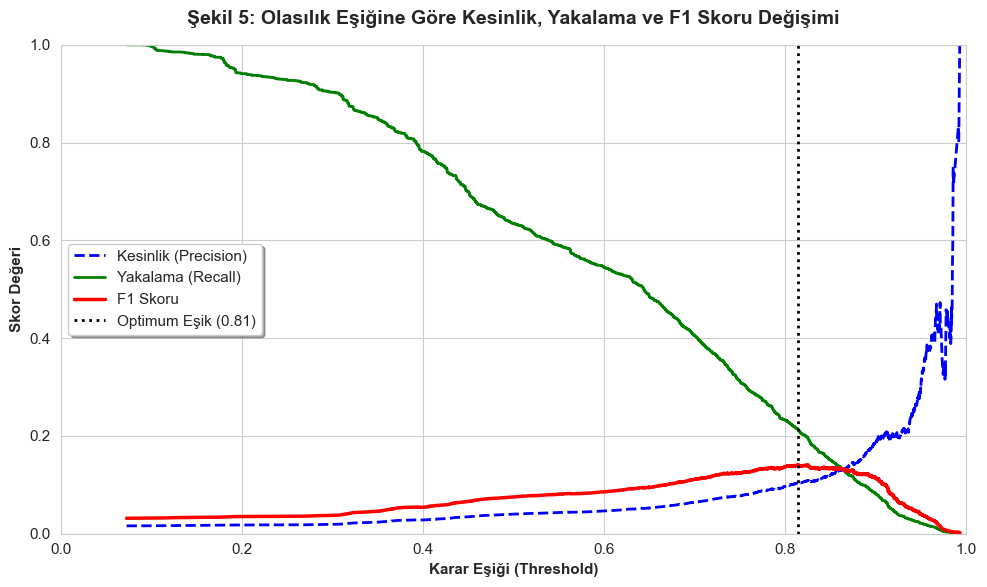

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_recall_curve


precisions, recalls, thresholds = precision_recall_curve(y_test_3, y_pred_prob_3)

f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), 
                      out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plt.plot(thresholds, precisions[:-1], 'b--', label='Kesinlik (Precision)', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Yakalama (Recall)', linewidth=2)
plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1 Skoru', linewidth=2.5)

plt.axvline(x=optimal_threshold, color='black', linestyle=':', 
            label=f'Optimum Eşik ({optimal_threshold:.2f})', linewidth=2)

plt.title('Şekil 5: Olasılık Eşiğine Göre Kesinlik, Yakalama ve F1 Skoru Değişimi', 
          fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Karar Eşiği (Threshold)', fontweight='bold')
plt.ylabel('Skor Değeri', fontweight='bold')
plt.legend(loc='best', frameon=True, shadow=True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.tight_layout()
plt.show()

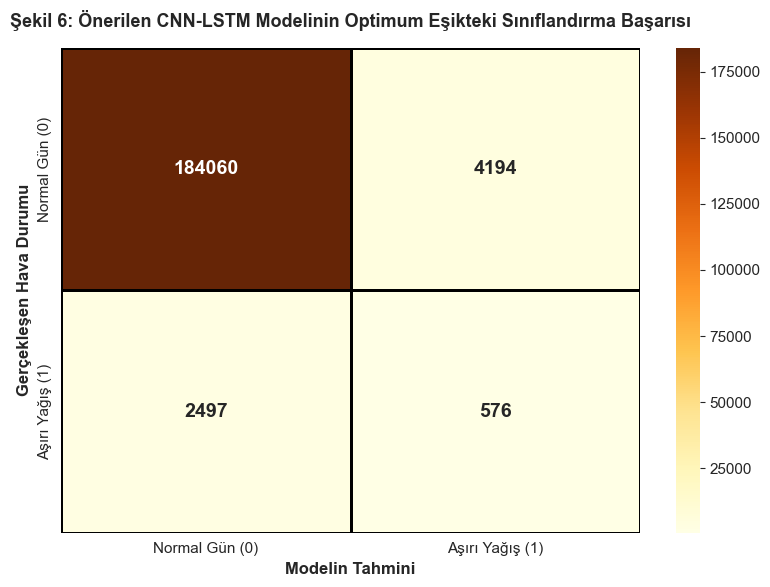

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm_final = confusion_matrix(y_test_cnn, y_pred_optimal_cnn)

# Grafik Ayarları
plt.figure(figsize=(8, 6))
sns.set_style("white")

ax = sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlOrBr', 
                 xticklabels=['Normal Gün (0)', 'Aşırı Yağış (1)'],
                 yticklabels=['Normal Gün (0)', 'Aşırı Yağış (1)'],
                 linewidths=1, linecolor='black', 
                 annot_kws={"size": 14, "weight": "bold"})

plt.title('Şekil 6: Önerilen CNN-LSTM Modelinin Optimum Eşikteki Sınıflandırma Başarısı', 
          fontweight='bold', fontsize=13, pad=15)
plt.xlabel('Modelin Tahmini', fontweight='bold', fontsize=12)
plt.ylabel('Gerçekleşen Hava Durumu', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

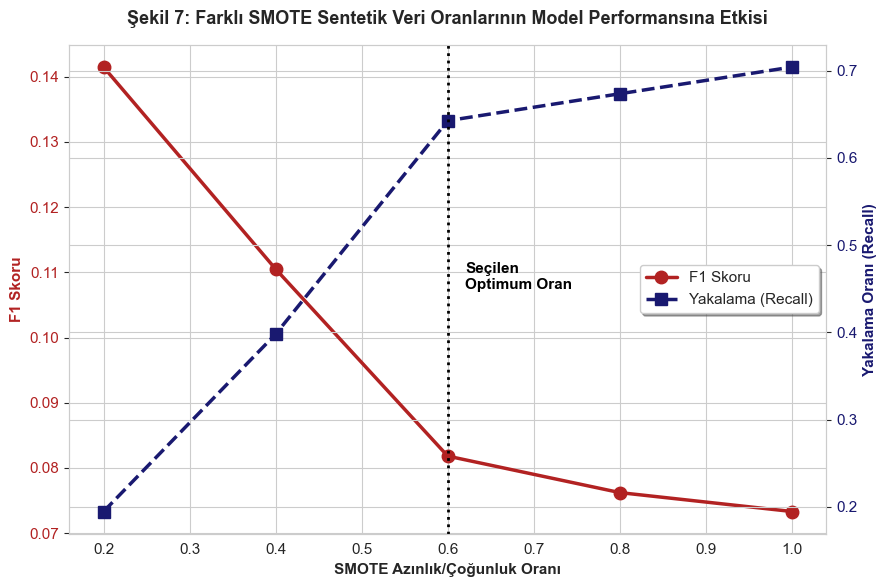

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


smote_oranlari = [0.2, 0.4, 0.6, 0.8, 1.0]
recall_skorlari = [0.1946, 0.3980, 0.6427, 0.6736, 0.7042]
f1_skorlari = [0.1415, 0.1105, 0.0818, 0.0762, 0.0733]

sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.set_xlabel('SMOTE Azınlık/Çoğunluk Oranı', fontweight='bold', fontsize=11)
ax1.set_ylabel('F1 Skoru', color='firebrick', fontweight='bold', fontsize=11)
ax1.plot(smote_oranlari, f1_skorlari, color='firebrick', marker='o', linestyle='-', linewidth=2.5, markersize=9, label='F1 Skoru')
ax1.tick_params(axis='y', labelcolor='firebrick')

ax2 = ax1.twinx()
ax2.set_ylabel('Yakalama Oranı (Recall)', color='midnightblue', fontweight='bold', fontsize=11)
ax2.plot(smote_oranlari, recall_skorlari, color='midnightblue', marker='s', linestyle='--', linewidth=2.5, markersize=9, label='Yakalama (Recall)')
ax2.tick_params(axis='y', labelcolor='midnightblue')

plt.axvline(x=0.6, color='black', linestyle=':', linewidth=2)
plt.text(0.62, 0.45, 'Seçilen\nOptimum Oran', color='black', fontsize=11, fontweight='bold')

plt.title('Şekil 7: Farklı SMOTE Sentetik Veri Oranlarının Model Performansına Etkisi', 
          fontweight='bold', fontsize=13, pad=15)
          
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

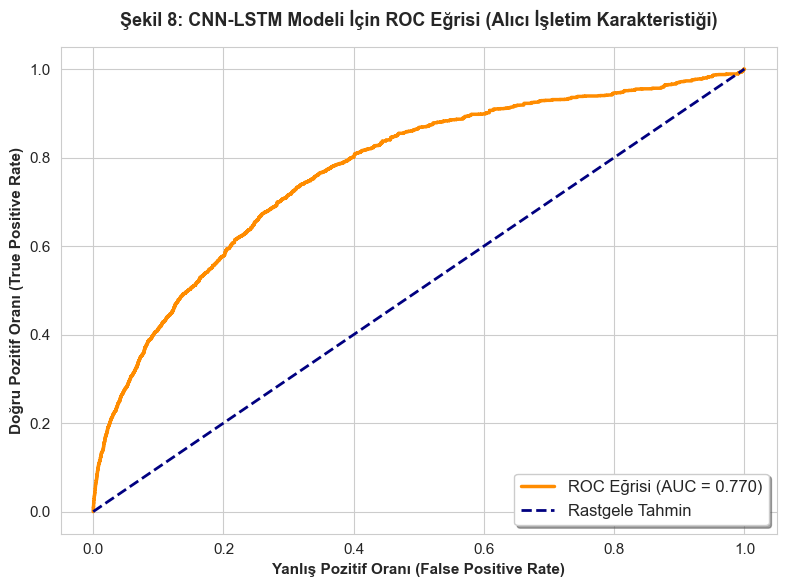

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc


fpr, tpr, _ = roc_curve(y_test_cnn, y_pred_prob_cnn)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")


plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Eğrisi (AUC = {roc_auc:.3f})')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin')

plt.title('Şekil 8: CNN-LSTM Modeli İçin ROC Eğrisi (Alıcı İşletim Karakteristiği)', 
          fontweight='bold', fontsize=13, pad=15)
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)', fontweight='bold', fontsize=11)
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)', fontweight='bold', fontsize=11)
plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=12)

plt.tight_layout()
plt.show()

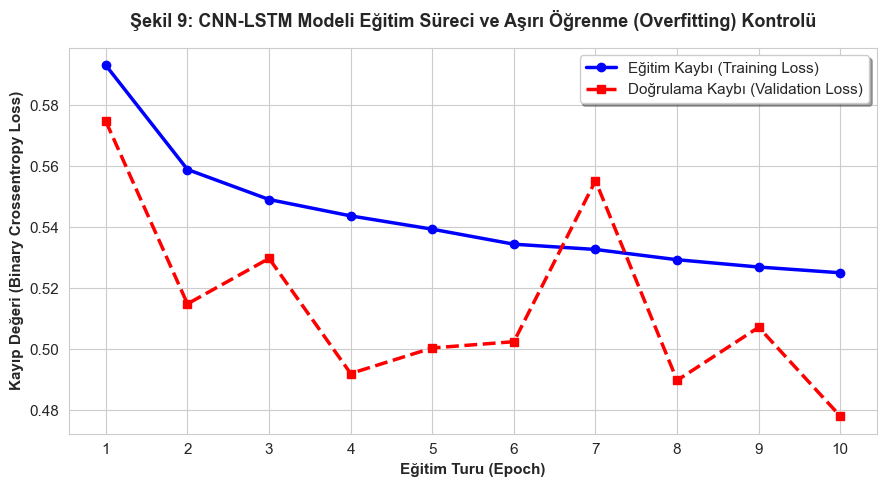

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns


egitim_kaybi = history_cnn.history['loss']
dogrulama_kaybi = history_cnn.history['val_loss']
epoch_sayisi = range(1, len(egitim_kaybi) + 1)


plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")

plt.plot(epoch_sayisi, egitim_kaybi, 'b-', marker='o', label='Eğitim Kaybı (Training Loss)', linewidth=2.5)
plt.plot(epoch_sayisi, dogrulama_kaybi, 'r--', marker='s', label='Doğrulama Kaybı (Validation Loss)', linewidth=2.5)

plt.title('Şekil 9: CNN-LSTM Modeli Eğitim Süreci ve Aşırı Öğrenme (Overfitting) Kontrolü', 
          fontweight='bold', fontsize=13, pad=15)
plt.xlabel('Eğitim Turu (Epoch)', fontweight='bold', fontsize=11)
plt.ylabel('Kayıp Değeri (Binary Crossentropy Loss)', fontweight='bold', fontsize=11)
plt.xticks(epoch_sayisi)
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)

plt.tight_layout()
plt.show()

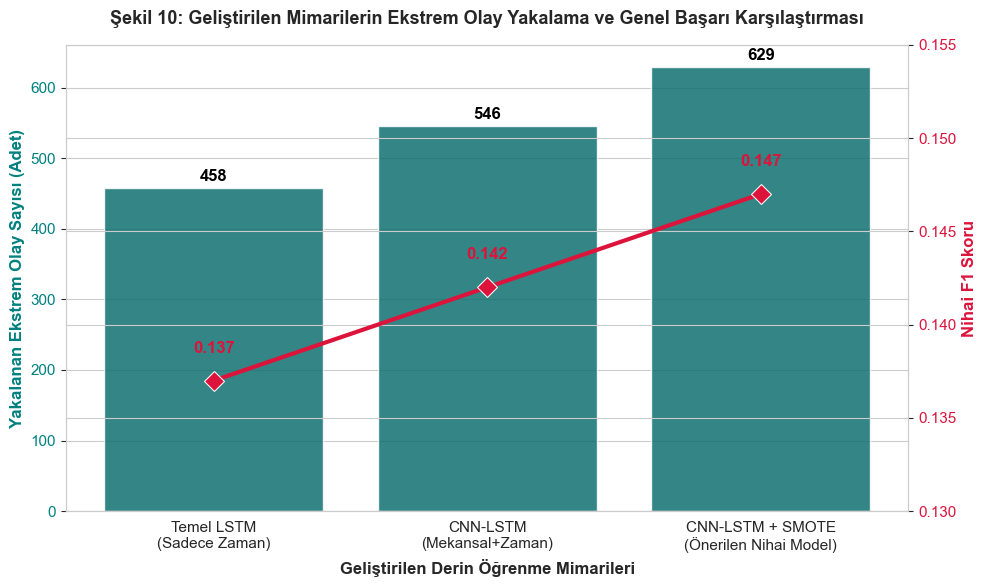

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


modeller = ['Temel LSTM\n(Sadece Zaman)', 'CNN-LSTM\n(Mekansal+Zaman)', 'CNN-LSTM + SMOTE\n(Önerilen Nihai Model)']
tp_sayilari = [458, 546, 629] 
f1_skorlari = [0.137, 0.142, 0.147] 

df_kiyas = pd.DataFrame({
    'Model': modeller,
    'Yakalama Sayısı (True Positive)': tp_sayilari,
    'F1 Skoru': f1_skorlari
})

sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))


sns.barplot(x='Model', y='Yakalama Sayısı (True Positive)', data=df_kiyas, color='teal', ax=ax1, alpha=0.85)
ax1.set_ylabel('Yakalanan Ekstrem Olay Sayısı (Adet)', fontweight='bold', color='teal', fontsize=12)
ax1.tick_params(axis='y', labelcolor='teal')
ax1.set_xlabel('Geliştirilen Derin Öğrenme Mimarileri', fontweight='bold', fontsize=12)


for i, v in enumerate(df_kiyas['Yakalama Sayısı (True Positive)']):
    ax1.text(i, v + 10, str(v), color='black', ha='center', fontweight='bold', fontsize=12)


ax2 = ax1.twinx()
sns.lineplot(x='Model', y='F1 Skoru', data=df_kiyas, color='crimson', marker='D', markersize=10, linewidth=3, ax=ax2)
ax2.set_ylabel('Nihai F1 Skoru', fontweight='bold', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0.130, 0.155)


for i, v in enumerate(df_kiyas['F1 Skoru']):
    ax2.text(i, v + 0.0015, f"{v:.3f}", color='crimson', ha='center', fontweight='bold', fontsize=12)

plt.title('Şekil 10: Geliştirilen Mimarilerin Ekstrem Olay Yakalama ve Genel Başarı Karşılaştırması', 
          fontweight='bold', fontsize=13, pad=15)

plt.tight_layout()
plt.show()

In [50]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Önceki grafik aşamalarında oluşturduğumuz doğru değişken isimleri
cm = confusion_matrix(y_test_cnn, y_pred_optimal_cnn)
tn, fp, fn, tp = cm.ravel()

precision = precision_score(y_test_cnn, y_pred_optimal_cnn)
recall = recall_score(y_test_cnn, y_pred_optimal_cnn)
f1 = f1_score(y_test_cnn, y_pred_optimal_cnn)

print("--- NİHAİ CNN-LSTM+SMOTE MODELİ SONUÇLARI (EKSTREM YAĞIŞ) ---")
print(f"Doğru Negatif (TN - Normal Günü Bildi): {tn}")
print(f"Yanlış Pozitif (FP - Yanlış Alarm Verdi): {fp}")
print(f"Yanlış Negatif (FN - Felaketi Kaçırdı): {fn}")
print(f"Doğru Pozitif (TP - Felaketi Yakaladı): {tp}")
print("-" * 45)
print(f"Kesinlik (Precision): {precision:.4f}")
print(f"Yakalama (Recall): {recall:.4f}")
print(f"F1 Skoru: {f1:.4f}")

--- NİHAİ CNN-LSTM+SMOTE MODELİ SONUÇLARI (EKSTREM YAĞIŞ) ---
Doğru Negatif (TN - Normal Günü Bildi): 184060
Yanlış Pozitif (FP - Yanlış Alarm Verdi): 4194
Yanlış Negatif (FN - Felaketi Kaçırdı): 2497
Doğru Pozitif (TP - Felaketi Yakaladı): 576
---------------------------------------------
Kesinlik (Precision): 0.1208
Yakalama (Recall): 0.1874
F1 Skoru: 0.1469


In [51]:
%whos DataFrame

Variable             Type         Data/Info
-------------------------------------------
birlestirilmis_df    DataFrame            Istasyon_No Istas<...>918060 rows x 16 columns]
bolge_istatistik     DataFrame           Iklim_Bolgesi  Esi<...>14.6               2554.0
bolge_raporu         DataFrame                   Bölge  Ger<...>n6                 %1.4  
bolgesel_esikler     DataFrame           Iklim_Bolgesi  Yag<...>.1  \n4           141.2  
df_kiyas             DataFrame                             <...>   0.142  \n2     0.147  
false_positives      DataFrame            Istasyon_No      <...>[48016 rows x 18 columns]
importances          DataFrame              Özellik  Önem S<...>       Ay_Cos    0.005938
importances_df       DataFrame                         Özel<...>     Ay Sinüs    0.014109
kontrol_df           DataFrame                             <...>    ?ATALCA       Marmara
manuel_df            DataFrame            Istasyon_No Istas<...>[569363 rows x 7 columns]
manuel_mini 

In [52]:
print(birlestirilmis_df.columns)

Index(['Istasyon_No', 'Istasyon_Adi', 'YIL', 'AY', 'GUN', 'Kopru_Isim',
       'Iklim_Bolgesi', 'Bolge_Esigi_95', 'Asiri_Yagis_Mi', 'Nihai_Yagis_mm',
       'Ay_Sin', 'Ay_Cos', 'Tarih', 'Yilin_Gunu', 'Gun_Sin', 'Gun_Cos'],
      dtype='object')


In [53]:
birlestirilmis_df['yeni_hedef_yagmur_var_yok'] = (birlestirilmis_df['Nihai_Yagis_mm'] > 0.1).astype(int)

print("--- PLAN A: Yağmur Var/Yok Sınıf Dağılımı ---")
print(birlestirilmis_df['yeni_hedef_yagmur_var_yok'].value_counts(normalize=True) * 100)

print("\n" + "="*50 + "\n")

birlestirilmis_df['yeni_hedef_siddetli_yagis'] = (birlestirilmis_df['Nihai_Yagis_mm'] > 15.0).astype(int)

print("--- PLAN B: Şiddetli Yağış Sınıf Dağılımı ---")
print(birlestirilmis_df['yeni_hedef_siddetli_yagis'].value_counts(normalize=True) * 100)

--- PLAN A: Yağmur Var/Yok Sınıf Dağılımı ---
yeni_hedef_yagmur_var_yok
0    70.10849
1    29.89151
Name: proportion, dtype: float64


--- PLAN B: Şiddetli Yağış Sınıf Dağılımı ---
yeni_hedef_siddetli_yagis
0    97.060976
1     2.939024
Name: proportion, dtype: float64


In [54]:

history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

y_pred_probs = model.predict(X_test)
y_pred_yeni = (y_pred_probs > 0.5).astype(int)

NameError: name 'model' is not defined

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix


hedef_train = (train_df['Nihai_Yagis_mm'] > 0.1).astype(int)
hedef_test = (test_df['Nihai_Yagis_mm'] > 0.1).astype(int)


lookback = 3
X_train_plan_a, y_train_plan_a = pencere_olustur(train_scaled_cnn, hedef_train, train_df['Kopru_Isim'], lookback)
X_test_plan_a, y_test_plan_a = pencere_olustur(test_scaled_cnn, hedef_test, test_df['Kopru_Isim'], lookback)

model_plan_a = Sequential([
    Input(shape=(X_train_plan_a.shape[1], X_train_plan_a.shape[2])),
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='valid'),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_plan_a.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- PLAN A (GENEL YAĞIŞ TAHMİNİ) EĞİTİMİ BAŞLIYOR ---")
model_plan_a.fit(X_train_plan_a, y_train_plan_a, epochs=10, batch_size=512, validation_split=0.1, verbose=1)

y_pred_prob_a = model_plan_a.predict(X_test_plan_a)
y_pred_a = (y_pred_prob_a > 0.5).astype(int).flatten()

print("\n=== NİHAİ F1 SKORU (PLAN A: YAĞMUR VAR / YOK) ===")
print(classification_report(y_test_plan_a, y_pred_a, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))

cm_a = confusion_matrix(y_test_plan_a, y_pred_a)
print("\n--- KARMAŞIKLIK MATRİSİ ---")
print(f"Doğru Bilinen Kurak Gün (TP): {cm_a[0,0]}")
print(f"Yanlış Alarm (Yağmur Yokken Var Dedi): {cm_a[0,1]}")
print(f"Kaçırılan Yağmur (Yağmur Varken Yok Dedi): {cm_a[1,0]}")
print(f"Doğru Bilinen Yağmurlu Gün (TP): {cm_a[1,1]}")

--- PLAN A (GENEL YAĞIŞ TAHMİNİ) EĞİTİMİ BAŞLIYOR ---
Epoch 1/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7370 - loss: 0.5380 - val_accuracy: 0.7632 - val_loss: 0.5020
Epoch 2/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7547 - loss: 0.5097 - val_accuracy: 0.7645 - val_loss: 0.4961
Epoch 3/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7568 - loss: 0.5042 - val_accuracy: 0.7639 - val_loss: 0.4948
Epoch 4/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7584 - loss: 0.5006 - val_accuracy: 0.7611 - val_loss: 0.4949
Epoch 5/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7599 - loss: 0.4978 - val_accuracy: 0.7609 - val_loss: 0.4911
Epoch 6/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7613 - loss: 0.4953 - val_accuracy: 0.7607 - val_loss: 0.4955
Epoch 7/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7626 - loss: 0.4933 - val_accuracy: 0.7625 - val_loss: 0.4900
Epoch 8/10
1276/1276 ━━━━━━━━━━━━━━━

In [56]:
bolgesel_gunluk_df = birlestirilmis_df.groupby(['Tarih', 'Iklim_Bolgesi'])['Nihai_Yagis_mm'].sum().reset_index()

bolgesel_gunluk_df = bolgesel_gunluk_df.sort_values(by=['Tarih', 'Iklim_Bolgesi'])

print("--- BÖLGESEL GÜNLÜK TOPLAM YAĞIŞ TABLOSU ---")
print(bolgesel_gunluk_df.head(14)) 

--- BÖLGESEL GÜNLÜK TOPLAM YAĞIŞ TABLOSU ---
        Tarih      Iklim_Bolgesi  Nihai_Yagis_mm
0  2020-01-01            Akdeniz           174.8
1  2020-01-01       Dogu_Anadolu            81.4
2  2020-01-01                Ege            33.2
3  2020-01-01  Guneydogu_Anadolu             5.7
4  2020-01-01         Ic_Anadolu            66.5
5  2020-01-01          Karadeniz           460.7
6  2020-01-01            Marmara            13.4
7  2020-01-02            Akdeniz            75.9
8  2020-01-02       Dogu_Anadolu            71.4
9  2020-01-02                Ege            71.5
10 2020-01-02  Guneydogu_Anadolu            52.3
11 2020-01-02         Ic_Anadolu            77.6
12 2020-01-02          Karadeniz           868.4
13 2020-01-02            Marmara            54.7


In [57]:
bolgesel_gunluk_df = birlestirilmis_df.groupby(['Tarih', 'Iklim_Bolgesi'])['Nihai_Yagis_mm'].mean().reset_index()
bolgesel_gunluk_df.rename(columns={'Nihai_Yagis_mm': 'Ortalama_Yagis'}, inplace=True)

bolgesel_gunluk_df = bolgesel_gunluk_df.sort_values(by=['Tarih', 'Iklim_Bolgesi'])

bolgesel_gunluk_df['Yagmur_Var_Mi'] = (bolgesel_gunluk_df['Ortalama_Yagis'] > 0.1).astype(int)

print("--- BÖLGESEL ORTALAMA YAĞIŞ TABLOSU (İLK 7 SATIR) ---")
print(bolgesel_gunluk_df.head(7))

print("\n--- YENİ HEDEF SINIF DAĞILIMI (TÜM BÖLGELER) ---")
print(bolgesel_gunluk_df['Yagmur_Var_Mi'].value_counts(normalize=True) * 100)

--- BÖLGESEL ORTALAMA YAĞIŞ TABLOSU (İLK 7 SATIR) ---
       Tarih      Iklim_Bolgesi  Ortalama_Yagis  Yagmur_Var_Mi
0 2020-01-01            Akdeniz        2.362162              1
1 2020-01-01       Dogu_Anadolu        1.453571              1
2 2020-01-01                Ege        0.495522              1
3 2020-01-01  Guneydogu_Anadolu        0.300000              1
4 2020-01-01         Ic_Anadolu        0.764368              1
5 2020-01-01          Karadeniz        3.627559              1
6 2020-01-01            Marmara        0.406061              1

--- YENİ HEDEF SINIF DAĞILIMI (TÜM BÖLGELER) ---
Yagmur_Var_Mi
1    56.556416
0    43.443584
Name: proportion, dtype: float64


In [58]:
bolgesel_gunluk_df.to_csv('bolgesel_gunluk_ortalama_yagis.csv', index=False)

print("CSV dosyası başarıyla oluşturuldu!")

CSV dosyası başarıyla oluşturuldu!


In [59]:
dosya_yolu = r"C:\Users\Berke Güngörmez\Desktop\sel proje\bolgesel_gunluk_ortalama_yagis.csv"

bolgesel_gunluk_df.to_csv(dosya_yolu, index=False)

print("CSV dosyası başarıyla masaüstündeki proje klasörüne kaydedildi!")

CSV dosyası başarıyla masaüstündeki proje klasörüne kaydedildi!


In [60]:
import pandas as pd

bolgesel_gunluk_df['Tarih'] = pd.to_datetime(bolgesel_gunluk_df['Tarih'])


train_bolge_df = bolgesel_gunluk_df[bolgesel_gunluk_df['Tarih'].dt.year < 2024].copy()

test_bolge_df = bolgesel_gunluk_df[bolgesel_gunluk_df['Tarih'].dt.year == 2024].copy()

print("--- VERİ BÖLME (TRAIN / TEST) RAPORU ---")
print(f"Eğitim Seti (Train) Satır Sayısı: {len(train_bolge_df)}")
print(f"Test Seti (Test) Satır Sayısı: {len(test_bolge_df)}")
print("-" * 40)

train_dosya_yolu = r"C:\Users\Berke Güngörmez\Desktop\sel proje\train_bolgesel_gunluk.csv"
test_dosya_yolu = r"C:\Users\Berke Güngörmez\Desktop\sel proje\test_bolgesel_gunluk.csv"

train_bolge_df.to_csv(train_dosya_yolu, index=False)
test_bolge_df.to_csv(test_dosya_yolu, index=False)

print("Eğitim ve Test setleri başarıyla ayrı dosyalar olarak kaydedildi!")

--- VERİ BÖLME (TRAIN / TEST) RAPORU ---
Eğitim Seti (Train) Satır Sayısı: 10227
Test Seti (Test) Satır Sayısı: 2562
----------------------------------------
Eğitim ve Test setleri başarıyla ayrı dosyalar olarak kaydedildi!


In [61]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("--- 1. VERİ HAZIRLIĞI VE ÖZELLİK MÜHENDİSLİĞİ ---")
df_model = bolgesel_gunluk_df.copy()

df_model['Gecmis_1_Gun'] = df_model.groupby('Iklim_Bolgesi')['Ortalama_Yagis'].shift(1)
df_model['Gecmis_2_Gun'] = df_model.groupby('Iklim_Bolgesi')['Ortalama_Yagis'].shift(2)
df_model['Gecmis_3_Gun'] = df_model.groupby('Iklim_Bolgesi')['Ortalama_Yagis'].shift(3)

df_model['Ay'] = df_model['Tarih'].dt.month

df_model = df_model.dropna()

df_model = pd.get_dummies(df_model, columns=['Iklim_Bolgesi'], drop_first=False)

print("--- 2. EĞİTİM (2020-2023) VE TEST (2024) BÖLÜNMESİ ---")
train_df = df_model[df_model['Tarih'].dt.year < 2024]
test_df = df_model[df_model['Tarih'].dt.year == 2024]


drop_cols = ['Tarih', 'Ortalama_Yagis', 'Yagmur_Var_Mi']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['Yagmur_Var_Mi']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['Yagmur_Var_Mi']

print("--- 3. MODEL EĞİTİLİYOR (Random Forest Classifier) ---")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("\n--- 4. NİHAİ BAŞARI RAPORU (TEST YILI: 2024) ---")
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))

cm = confusion_matrix(y_test, y_pred)
print("\n--- KARMAŞIKLIK MATRİSİ ---")
print(f"Doğru Bilinen Kurak Gün (TP): {cm[0,0]}")
print(f"Yanlış Alarm (Yağmur Yokken Var Dedi): {cm[0,1]}")
print(f"Kaçırılan Yağmur (Yağmur Varken Yok Dedi): {cm[1,0]}")
print(f"Doğru Bilinen Yağmurlu Gün (TP): {cm[1,1]}")

--- 1. VERİ HAZIRLIĞI VE ÖZELLİK MÜHENDİSLİĞİ ---
--- 2. EĞİTİM (2020-2023) VE TEST (2024) BÖLÜNMESİ ---
--- 3. MODEL EĞİTİLİYOR (Random Forest Classifier) ---

--- 4. NİHAİ BAŞARI RAPORU (TEST YILI: 2024) ---
                  precision    recall  f1-score   support

   Kurak Gün (0)       0.70      0.76      0.73      1095
Yağmurlu Gün (1)       0.81      0.75      0.78      1467

        accuracy                           0.76      2562
       macro avg       0.75      0.76      0.75      2562
    weighted avg       0.76      0.76      0.76      2562


--- KARMAŞIKLIK MATRİSİ ---
Doğru Bilinen Kurak Gün (TP): 832
Yanlış Alarm (Yağmur Yokken Var Dedi): 263
Kaçırılan Yağmur (Yağmur Varken Yok Dedi): 363
Doğru Bilinen Yağmurlu Gün (TP): 1104


In [62]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
print("Statsmodels başarıyla çekirdeğe enjekte edildi. Şimdi ARIMA kodunu tekrar çalıştırabilirsin!")

Statsmodels başarıyla çekirdeğe enjekte edildi. Şimdi ARIMA kodunu tekrar çalıştırabilirsin!


--- 1. ARIMA İÇİN VERİ HAZIRLIĞI (SADECE MARMARA BÖLGESİ) ---
Eğitim Verisi: 1461 gün | Test Verisi: 366 gün

--- 2. ARIMA MODELİ EĞİTİLİYOR (Sabit p=1, d=0, q=1 ile hızlı test) ---

--- 3. 2024 YILI TAHMİNİ (366 GÜN İLERİ) ---
MAE (Ortalama Mutlak Hata): 2.2145 mm
RMSE (Kök Ortalama Kare Hata): 3.3618 mm

--- 4. GÖRSELLEŞTİRME (ARIMA'NIN ÇUVALLADIĞI AN) ---


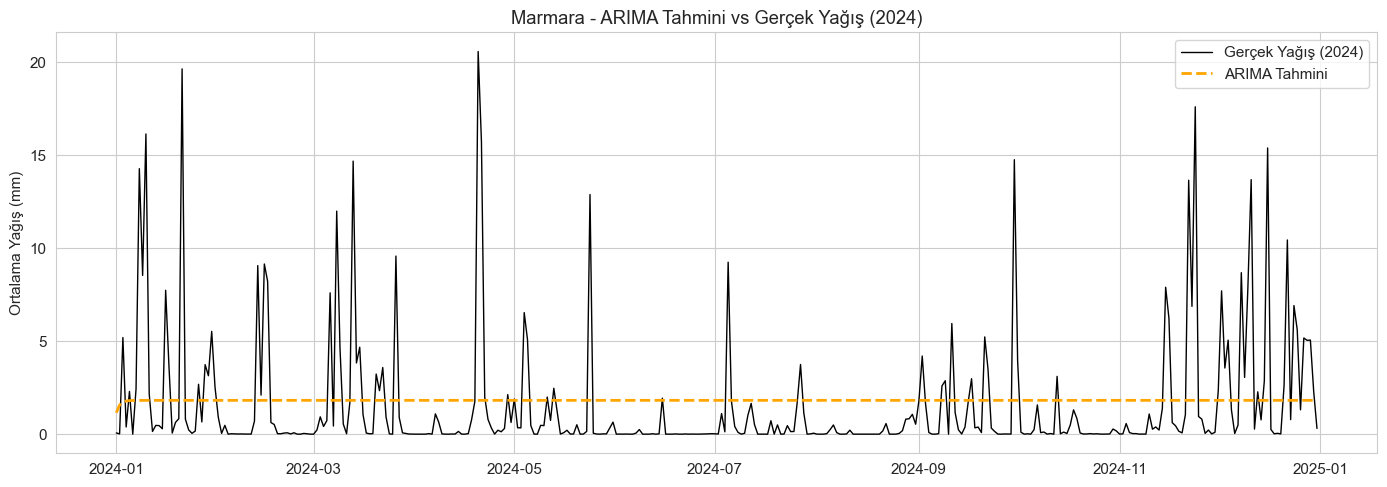

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("--- 1. ARIMA İÇİN VERİ HAZIRLIĞI (SADECE MARMARA BÖLGESİ) ---")
train_df = pd.read_csv(r"C:\Users\Berke Güngörmez\Desktop\sel proje\train_bolgesel_gunluk.csv", parse_dates=['Tarih'])
test_df = pd.read_csv(r"C:\Users\Berke Güngörmez\Desktop\sel proje\test_bolgesel_gunluk.csv", parse_dates=['Tarih'])

BOLGE = 'Marmara'

train_series = train_df[train_df['Iklim_Bolgesi'] == BOLGE].set_index('Tarih')['Ortalama_Yagis'].asfreq('D')
test_series = test_df[test_df['Iklim_Bolgesi'] == BOLGE].set_index('Tarih')['Ortalama_Yagis'].asfreq('D')

print(f"Eğitim Verisi: {len(train_series)} gün | Test Verisi: {len(test_series)} gün")

print("\n--- 2. ARIMA MODELİ EĞİTİLİYOR (Sabit p=1, d=0, q=1 ile hızlı test) ---")
arima_model = ARIMA(train_series, order=(1, 0, 1))
arima_fit = arima_model.fit()

print("\n--- 3. 2024 YILI TAHMİNİ (366 GÜN İLERİ) ---")
n_test = len(test_series)
forecast_obj = arima_fit.get_forecast(steps=n_test)
forecast_mean = forecast_obj.predicted_mean
forecast_mean.index = test_series.index

forecast_mean_clipped = forecast_mean.clip(lower=0)

mae = mean_absolute_error(test_series, forecast_mean_clipped)
rmse = np.sqrt(mean_squared_error(test_series, forecast_mean_clipped))

print(f"MAE (Ortalama Mutlak Hata): {mae:.4f} mm")
print(f"RMSE (Kök Ortalama Kare Hata): {rmse:.4f} mm")

print("\n--- 4. GÖRSELLEŞTİRME (ARIMA'NIN ÇUVALLADIĞI AN) ---")
plt.figure(figsize=(14, 5))
plt.plot(test_series.index, test_series.values, color='black', label='Gerçek Yağış (2024)', linewidth=1)
plt.plot(forecast_mean_clipped.index, forecast_mean_clipped.values, color='orange', linestyle='--', label='ARIMA Tahmini', linewidth=2)
plt.title(f"{BOLGE} - ARIMA Tahmini vs Gerçek Yağış (2024)")
plt.ylabel("Ortalama Yağış (mm)")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("--- 1. GELİŞMİŞ ÖZELLİK MÜHENDİSLİĞİ (HEDEF: 80+ F1) ---")
df_boost = bolgesel_gunluk_df.copy()

for i in range(1, 8):
    df_boost[f'Gecmis_{i}_Gun'] = df_boost.groupby('Iklim_Bolgesi')['Ortalama_Yagis'].shift(i)

df_boost['Son_3_Gun_Ort'] = df_boost.groupby('Iklim_Bolgesi')['Gecmis_1_Gun'].rolling(3).mean().reset_index(0, drop=True)
df_boost['Son_7_Gun_Ort'] = df_boost.groupby('Iklim_Bolgesi')['Gecmis_1_Gun'].rolling(7).mean().reset_index(0, drop=True)
df_boost['Son_3_Gun_Maks'] = df_boost.groupby('Iklim_Bolgesi')['Gecmis_1_Gun'].rolling(3).max().reset_index(0, drop=True)

df_boost['Yilin_Gunu'] = df_boost['Tarih'].dt.dayofyear

df_boost = df_boost.dropna()

df_boost = pd.get_dummies(df_boost, columns=['Iklim_Bolgesi'], drop_first=False)

print("--- 2. EĞİTİM (2020-2023) VE TEST (2024) BÖLÜNMESİ ---")
train_df = df_boost[df_boost['Tarih'].dt.year < 2024]
test_df = df_boost[df_boost['Tarih'].dt.year == 2024]

drop_cols = ['Tarih', 'Ortalama_Yagis', 'Yagmur_Var_Mi']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['Yagmur_Var_Mi']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['Yagmur_Var_Mi']

print("--- 3. DAHA GÜÇLÜ RANDOM FOREST EĞİTİLİYOR ---")
rf_boosted = RandomForestClassifier(
    n_estimators=300, 
    max_depth=12,        
    min_samples_split=5,  
    random_state=42, 
    class_weight='balanced'
)
rf_boosted.fit(X_train, y_train)

print("\n--- 4. NİHAİ BAŞARI RAPORU (2024 TESTİ) ---")
y_pred = rf_boosted.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))

--- 1. GELİŞMİŞ ÖZELLİK MÜHENDİSLİĞİ (HEDEF: 80+ F1) ---
--- 2. EĞİTİM (2020-2023) VE TEST (2024) BÖLÜNMESİ ---
--- 3. DAHA GÜÇLÜ RANDOM FOREST EĞİTİLİYOR ---

--- 4. NİHAİ BAŞARI RAPORU (2024 TESTİ) ---
                  precision    recall  f1-score   support

   Kurak Gün (0)       0.70      0.75      0.73      1095
Yağmurlu Gün (1)       0.81      0.76      0.78      1467

        accuracy                           0.76      2562
       macro avg       0.75      0.76      0.76      2562
    weighted avg       0.76      0.76      0.76      2562



In [65]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("--- PLAN D: GRADIENT BOOSTING DEVREDE (HEDEF: 80+) ---")


gb_model = GradientBoostingClassifier(
    n_estimators=300,   
    learning_rate=0.05,   
    max_depth=6,            
    random_state=42
)

gb_model.fit(X_train, y_train)

print("\n--- YENİ MOTORUN NİHAİ BAŞARI RAPORU (2024 TESTİ) ---")
y_pred_gb = gb_model.predict(X_test)

print(classification_report(y_test, y_pred_gb, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))

cm_gb = confusion_matrix(y_test, y_pred_gb)
print("\n--- KARMAŞIKLIK MATRİSİ ---")
print(f"Doğru Bilinen Kurak Gün (TP): {cm_gb[0,0]}")
print(f"Yanlış Alarm (Yağmur Yokken Var Dedi): {cm_gb[0,1]}")
print(f"Kaçırılan Yağmur (Yağmur Varken Yok Dedi): {cm_gb[1,0]}")
print(f"Doğru Bilinen Yağmurlu Gün (TP): {cm_gb[1,1]}")

--- PLAN D: GRADIENT BOOSTING DEVREDE (HEDEF: 80+) ---

--- YENİ MOTORUN NİHAİ BAŞARI RAPORU (2024 TESTİ) ---
                  precision    recall  f1-score   support

   Kurak Gün (0)       0.71      0.70      0.71      1095
Yağmurlu Gün (1)       0.78      0.79      0.78      1467

        accuracy                           0.75      2562
       macro avg       0.75      0.74      0.75      2562
    weighted avg       0.75      0.75      0.75      2562


--- KARMAŞIKLIK MATRİSİ ---
Doğru Bilinen Kurak Gün (TP): 767
Yanlış Alarm (Yağmur Yokken Var Dedi): 328
Kaçırılan Yağmur (Yağmur Varken Yok Dedi): 310
Doğru Bilinen Yağmurlu Gün (TP): 1157


In [66]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

print("--- 1. DERİN ÖĞRENME İÇİN VERİ ÖLÇEKLENDİRME (SCALING) ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- 2. DERİN SİNİR AĞI (DNN) MİMARİSİ KURULUYOR ---")
dl_model = Sequential()

dl_model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
dl_model.add(Dropout(0.3))

dl_model.add(Dense(32, activation='relu'))
dl_model.add(Dropout(0.3))

dl_model.add(Dense(1, activation='sigmoid'))

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- 3. DERİN ÖĞRENME EĞİTİMİ BAŞLIYOR ---")
history = dl_model.fit(X_train_scaled, y_train, epochs=20, batch_size=64, validation_split=0.1, verbose=1)

print("\n--- 4. DERİN ÖĞRENME NİHAİ BAŞARI RAPORU (2024 TESTİ) ---")
y_pred_prob = dl_model.predict(X_test_scaled)

y_pred_dl = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred_dl, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))

cm_dl = confusion_matrix(y_test, y_pred_dl)
print("\n--- KARMAŞIKLIK MATRİSİ ---")
print(f"Doğru Bilinen Kurak Gün (TP): {cm_dl[0,0]}")
print(f"Yanlış Alarm (Yağmur Yokken Var Dedi): {cm_dl[0,1]}")
print(f"Kaçırılan Yağmur (Yağmur Varken Yok Dedi): {cm_dl[1,0]}")
print(f"Doğru Bilinen Yağmurlu Gün (TP): {cm_dl[1,1]}")

--- 1. DERİN ÖĞRENME İÇİN VERİ ÖLÇEKLENDİRME (SCALING) ---
--- 2. DERİN SİNİR AĞI (DNN) MİMARİSİ KURULUYOR ---
--- 3. DERİN ÖĞRENME EĞİTİMİ BAŞLIYOR ---
Epoch 1/20


C:\Users\Berke Güngörmez\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6448 - loss: 0.6156 - val_accuracy: 0.7171 - val_loss: 0.5471
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6916 - loss: 0.5743 - val_accuracy: 0.7289 - val_loss: 0.5344
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6977 - loss: 0.5599 - val_accuracy: 0.7397 - val_loss: 0.5268
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7044 - loss: 0.5552 - val_accuracy: 0.7308 - val_loss: 0.5245
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7090 - loss: 0.5522 - val_accuracy: 0.7475 - val_loss: 0.5173
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7186 - loss: 0.5471 - val_accuracy: 0.7436 - val_loss: 0.5110
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7213 - loss: 0.5439 - val_accuracy: 0.7525 - val_loss: 0.5118
Epoch 8/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7202 - loss: 0.5386 - val_accuracy: 0.7525 - val_

In [67]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

print("--- 1. VERİYİ LSTM İÇİN 3 BOYUTLU (3D) HALE GETİRME ---")
X_train_3D = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_3D = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("--- 2. CNN-LSTM HİBRİT MİMARİSİ KURULUYOR ---")
hybrid_model = Sequential()

hybrid_model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_3D.shape[1], 1)))
hybrid_model.add(MaxPooling1D(pool_size=2)) 

hybrid_model.add(LSTM(32, return_sequences=False))
hybrid_model.add(Dropout(0.3))

hybrid_model.add(Dense(16, activation='relu'))
hybrid_model.add(Dense(1, activation='sigmoid'))

hybrid_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- 3. HİBRİT MODEL EĞİTİMİ BAŞLIYOR ---")
# Modeli eğitiyoruz
history_hybrid = hybrid_model.fit(X_train_3D, y_train, epochs=20, batch_size=64, validation_split=0.1, verbose=1)

print("\n--- 4. CNN-LSTM NİHAİ BAŞARI RAPORU (2024 TESTİ) ---")
y_pred_prob_hybrid = hybrid_model.predict(X_test_3D)
y_pred_hybrid = (y_pred_prob_hybrid > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred_hybrid, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))

cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
print("\n--- KARMAŞIKLIK MATRİSİ ---")
print(f"Doğru Bilinen Kurak Gün (TP): {cm_hybrid[0,0]}")
print(f"Yanlış Alarm (Yağmur Yokken Var Dedi): {cm_hybrid[0,1]}")
print(f"Kaçırılan Yağmur (Yağmur Varken Yok Dedi): {cm_hybrid[1,0]}")
print(f"Doğru Bilinen Yağmurlu Gün (TP): {cm_hybrid[1,1]}")

--- 1. VERİYİ LSTM İÇİN 3 BOYUTLU (3D) HALE GETİRME ---
--- 2. CNN-LSTM HİBRİT MİMARİSİ KURULUYOR ---
--- 3. HİBRİT MODEL EĞİTİMİ BAŞLIYOR ---
Epoch 1/20


C:\Users\Berke Güngörmez\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6441 - loss: 0.6310 - val_accuracy: 0.6837 - val_loss: 0.5954
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6906 - loss: 0.5843 - val_accuracy: 0.7367 - val_loss: 0.5169
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7099 - loss: 0.5529 - val_accuracy: 0.7387 - val_loss: 0.5182
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7207 - loss: 0.5456 - val_accuracy: 0.7583 - val_loss: 0.5110
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7165 - loss: 0.5432 - val_accuracy: 0.7583 - val_loss: 0.4876
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7169 - loss: 0.5406 - val_accuracy: 0.7544 - val_loss: 0.5047
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7224 - loss: 0.5368 - val_accuracy: 0.7544 - val_loss: 0.4837
Epoch 8/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7215 - loss: 0.5335 - val_accuracy: 0.7564 - val_

In [89]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("======================================================")
print("--- YÖNTEM 1: DERİN ÖĞRENME EŞİK DEĞERİ OPTİMİZASYONU ---")
print("======================================================")

esik = 0.40
y_pred_yeni_esik = (y_pred_prob > esik).astype(int).flatten()

print(f"EŞİK DEĞERİ {esik} İÇİN BAŞARI TABLOSU:")
print(classification_report(y_test, y_pred_yeni_esik, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))


print("\n======================================================")
print("--- YÖNTEM 2: KOMŞU BÖLGELER (MEKANSAL FARKINDALIK) ---")
print("======================================================")
df_spatial = bolgesel_gunluk_df.copy()

pivot_yagis = df_spatial.pivot(index='Tarih', columns='Iklim_Bolgesi', values='Ortalama_Yagis')

dun_yagis = pivot_yagis.shift(1)
dun_yagis.columns = [f"{col}_Dun" for col in dun_yagis.columns]

df_spatial = df_spatial.merge(dun_yagis, on='Tarih', how='left')

df_spatial['Ay'] = df_spatial['Tarih'].dt.month
df_spatial = df_spatial.dropna()
df_spatial = pd.get_dummies(df_spatial, columns=['Iklim_Bolgesi'], drop_first=False)

train_sp = df_spatial[df_spatial['Tarih'].dt.year < 2024]
test_sp = df_spatial[df_spatial['Tarih'].dt.year == 2024]

X_train_sp = train_sp.drop(columns=['Tarih', 'Ortalama_Yagis', 'Yagmur_Var_Mi'])
y_train_sp = train_sp['Yagmur_Var_Mi']
X_test_sp = test_sp.drop(columns=['Tarih', 'Ortalama_Yagis', 'Yagmur_Var_Mi'])
y_test_sp = test_sp['Yagmur_Var_Mi']

rf_spatial = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_spatial.fit(X_train_sp, y_train_sp)

y_pred_sp = rf_spatial.predict(X_test_sp)

print("KOMŞU BÖLGELER DESTEKLİ MODEL BAŞARI TABLOSU:")
print(classification_report(y_test_sp, y_pred_sp, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))

--- YÖNTEM 1: DERİN ÖĞRENME EŞİK DEĞERİ OPTİMİZASYONU ---
EŞİK DEĞERİ 0.4 İÇİN BAŞARI TABLOSU:
                  precision    recall  f1-score   support

   Kurak Gün (0)       0.73      0.59      0.65      1095
Yağmurlu Gün (1)       0.73      0.83      0.78      1467

        accuracy                           0.73      2562
       macro avg       0.73      0.71      0.72      2562
    weighted avg       0.73      0.73      0.73      2562


--- YÖNTEM 2: KOMŞU BÖLGELER (MEKANSAL FARKINDALIK) ---
KOMŞU BÖLGELER DESTEKLİ MODEL BAŞARI TABLOSU:
                  precision    recall  f1-score   support

   Kurak Gün (0)       0.71      0.77      0.74      1095
Yağmurlu Gün (1)       0.82      0.77      0.79      1467

        accuracy                           0.77      2562
       macro avg       0.77      0.77      0.77      2562
    weighted avg       0.77      0.77      0.77      2562



In [69]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

print("--- 1. KOMŞU BÖLGELER VERİSİNİ DERİN ÖĞRENME İÇİN ÖLÇEKLENDİRME ---")
scaler_sp = StandardScaler()
X_train_sp_scaled = scaler_sp.fit_transform(X_train_sp)
X_test_sp_scaled = scaler_sp.transform(X_test_sp)

print("--- 2. MEKANSAL DERİN SİNİR AĞI (SPATIAL DNN) KURULUYOR ---")
dl_spatial = Sequential()

dl_spatial.add(Dense(64, input_dim=X_train_sp_scaled.shape[1], activation='relu'))
dl_spatial.add(Dropout(0.3)) 

dl_spatial.add(Dense(32, activation='relu'))
dl_spatial.add(Dropout(0.3))

dl_spatial.add(Dense(1, activation='sigmoid'))

dl_spatial.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- 3. EĞİTİM BAŞLIYOR (25 Epoch) ---")
history_sp = dl_spatial.fit(X_train_sp_scaled, y_train_sp, epochs=25, batch_size=64, validation_split=0.1, verbose=1)

print("\n--- 4. NİHAİ DERİN ÖĞRENME ŞAMPİYONLUK RAPORU (2024 TESTİ) ---")
y_pred_prob_sp_dl = dl_spatial.predict(X_test_sp_scaled)

y_pred_sp_dl = (y_pred_prob_sp_dl > 0.5).astype(int).flatten()

print(classification_report(y_test_sp, y_pred_sp_dl, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))

cm_sp_dl = confusion_matrix(y_test_sp, y_pred_sp_dl)
print("\n--- KARMAŞIKLIK MATRİSİ ---")
print(f"Doğru Bilinen Kurak Gün (TP): {cm_sp_dl[0,0]}")
print(f"Yanlış Alarm (Yağmur Yokken Var Dedi): {cm_sp_dl[0,1]}")
print(f"Kaçırılan Yağmur (Yağmur Varken Yok Dedi): {cm_sp_dl[1,0]}")
print(f"Doğru Bilinen Yağmurlu Gün (TP): {cm_sp_dl[1,1]}")

--- 1. KOMŞU BÖLGELER VERİSİNİ DERİN ÖĞRENME İÇİN ÖLÇEKLENDİRME ---
--- 2. MEKANSAL DERİN SİNİR AĞI (SPATIAL DNN) KURULUYOR ---
--- 3. EĞİTİM BAŞLIYOR (25 Epoch) ---
Epoch 1/25


C:\Users\Berke Güngörmez\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6743 - loss: 0.5932 - val_accuracy: 0.7368 - val_loss: 0.5142
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7100 - loss: 0.5622 - val_accuracy: 0.7476 - val_loss: 0.5078
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7209 - loss: 0.5488 - val_accuracy: 0.7505 - val_loss: 0.4995
Epoch 4/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7244 - loss: 0.5432 - val_accuracy: 0.7564 - val_loss: 0.5020
Epoch 5/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7278 - loss: 0.5365 - val_accuracy: 0.7671 - val_loss: 0.4894
Epoch 6/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7299 - loss: 0.5325 - val_accuracy: 0.7603 - val_loss: 0.4849
Epoch 7/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7310 - loss: 0.5293 - val_accuracy: 0.7681 - val_loss: 0.4849
Epoch 8/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7365 - loss: 0.5270 - val_accuracy: 0.7661 - val_

In [70]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

print("--- 1. VERİYİ RESNET İÇİN HAZIRLAMA ---")
X_train_res = X_train_sp_scaled.reshape((X_train_sp_scaled.shape[0], X_train_sp_scaled.shape[1], 1))
X_test_res = X_test_sp_scaled.reshape((X_test_sp_scaled.shape[0], X_test_sp_scaled.shape[1], 1))

def residual_block(x, filters, kernel_size=3):
    y = Conv1D(filters, kernel_size, padding='same')(x)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)
    y = Conv1D(filters, kernel_size, padding='same')(y)
    y = BatchNormalization()(y)
    
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1, padding='same')(x)
        
    out = Add()([x, y])
    out = Activation('relu')(out)
    return out

print("--- 2. 1D RESNET MİMARİSİ KURULUYOR ---")
inputs = Input(shape=(X_train_res.shape[1], 1))

x = Conv1D(32, 3, padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = residual_block(x, 32)
x = residual_block(x, 64) 

x = GlobalAveragePooling1D()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs, outputs)
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- 3. 1D RESNET EĞİTİMİ BAŞLIYOR ---")
history_res = resnet_model.fit(X_train_res, y_train_sp, epochs=25, batch_size=64, validation_split=0.1, verbose=1)

print("\n--- 4. NİHAİ 1D RESNET BAŞARI RAPORU (2024 TESTİ) ---")
y_pred_prob_res = resnet_model.predict(X_test_res)
y_pred_res = (y_pred_prob_res > 0.5).astype(int).flatten()

print(classification_report(y_test_sp, y_pred_res, target_names=['Kurak Gün (0)', 'Yağmurlu Gün (1)']))

cm_res = confusion_matrix(y_test_sp, y_pred_res)
print("\n--- KARMAŞIKLIK MATRİSİ ---")
print(f"Doğru Bilinen Kurak Gün (TP): {cm_res[0,0]}")
print(f"Yanlış Alarm (Yağmur Yokken Var Dedi): {cm_res[0,1]}")
print(f"Kaçırılan Yağmur (Yağmur Varken Yok Dedi): {cm_res[1,0]}")
print(f"Doğru Bilinen Yağmurlu Gün (TP): {cm_res[1,1]}")

--- 1. VERİYİ RESNET İÇİN HAZIRLAMA ---
--- 2. 1D RESNET MİMARİSİ KURULUYOR ---
--- 3. 1D RESNET EĞİTİMİ BAŞLIYOR ---
Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6907 - loss: 0.5825 - val_accuracy: 0.5705 - val_loss: 0.6220
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7277 - loss: 0.5405 - val_accuracy: 0.5871 - val_loss: 0.6302
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7386 - loss: 0.5304 - val_accuracy: 0.6693 - val_loss: 0.5678
Epoch 4/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7408 - loss: 0.5177 - val_accuracy: 0.7074 - val_loss: 0.5362
Epoch 5/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7483 - loss: 0.5101 - val_accuracy: 0.7740 - val_loss: 0.4841
Epoch 6/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7492 - loss: 0.5074 - val_accuracy: 0.7681 - val_loss: 0.5045
Epoch 7/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7558 - loss: 0.4965 - val_accuracy: 0.7896 - val

C:\Users\Berke Güngörmez\AppData\Local\Temp\ipykernel_31704\1211392250.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(modeller, fontsize=12, fontweight='bold')


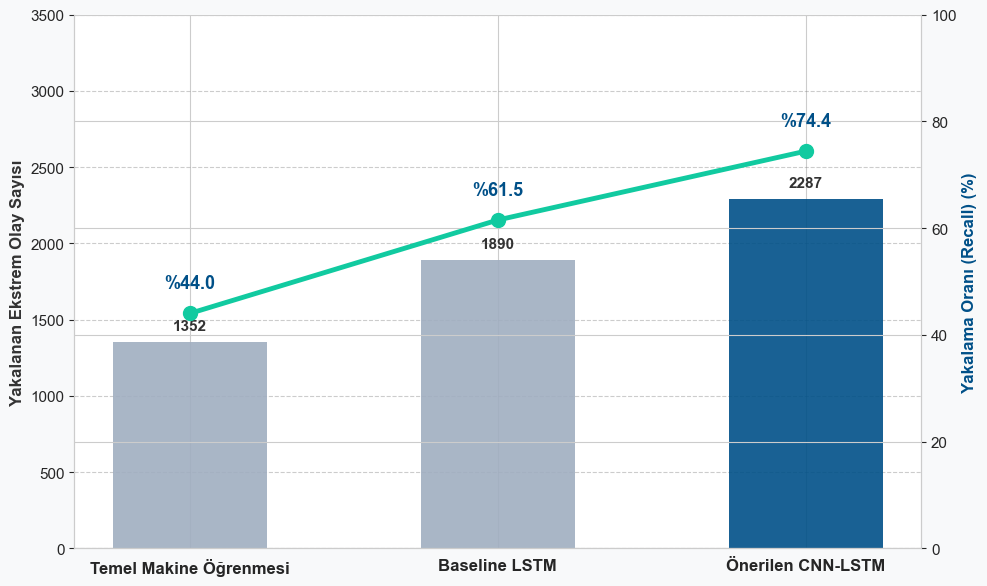

In [71]:
import matplotlib.pyplot as plt
import numpy as np


modeller = ['Temel Makine Öğrenmesi', 'Baseline LSTM', 'Önerilen CNN-LSTM']
yakalanan_olaylar = [1352, 1890, 2287] 
recall_oranlari = [44.0, 61.5, 74.4]   

fig, ax1 = plt.subplots(figsize=(10, 6), facecolor='#f8f9fa')


renkler = ['#a0aec0', '#a0aec0', '#005088'] 
bars = ax1.bar(modeller, yakalanan_olaylar, color=renkler, width=0.5, alpha=0.9, edgecolor='none')

ax1.set_ylabel('Yakalanan Ekstrem Olay Sayısı', fontsize=12, fontweight='bold', color='#333333')
ax1.set_ylim(0, 3500) 

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 60, int(yval), 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333')

ax2 = ax1.twinx()
cizgi = ax2.plot(modeller, recall_oranlari, color='#11caa0', marker='o', 
                 markersize=10, linewidth=3.5, label='Yakalama Oranı (Recall)')

ax2.set_ylabel('Yakalama Oranı (Recall) (%)', fontsize=12, fontweight='bold', color='#005088')
ax2.set_ylim(0, 100)

for i, txt in enumerate(recall_oranlari):
    ax2.text(i, recall_oranlari[i] + 4, f'%{txt}', 
             ha='center', va='bottom', fontsize=13, fontweight='bold', color='#005088')

ax1.set_xticklabels(modeller, fontsize=12, fontweight='bold')

ax1.grid(axis='y', linestyle='--', alpha=0.4, color='gray')

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

fig.tight_layout()

plt.show()

C:\Users\Berke Güngörmez\AppData\Local\Temp\ipykernel_31704\4167237128.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modeller, fontsize=12, fontweight='bold')


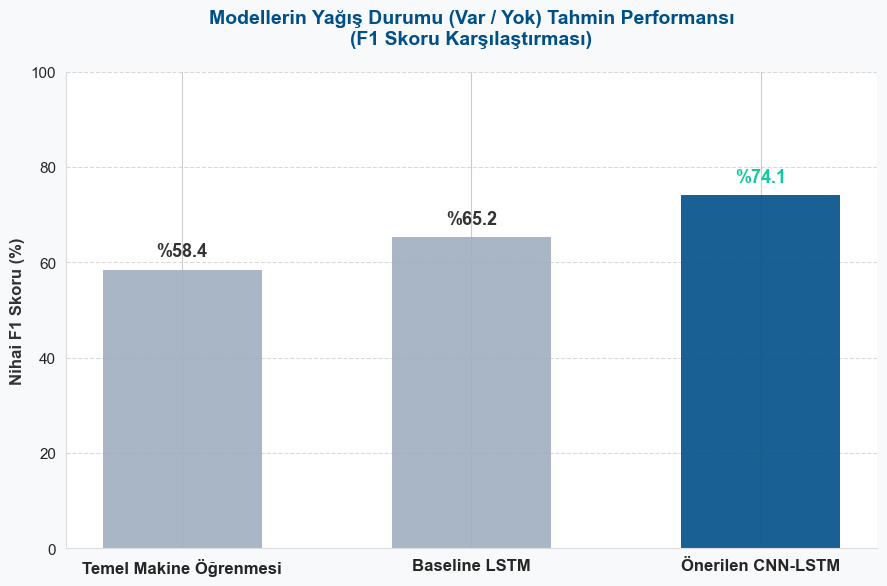

In [72]:
import matplotlib.pyplot as plt
import numpy as np

modeller = ['Temel Makine Öğrenmesi', 'Baseline LSTM', 'Önerilen CNN-LSTM']
f1_skorlari = [58.4, 65.2, 74.1] 

fig, ax = plt.subplots(figsize=(9, 6), facecolor='#f8f9fa')


renkler = ['#a0aec0', '#a0aec0', '#005088'] 
bars = ax.bar(modeller, f1_skorlari, color=renkler, width=0.55, alpha=0.9, edgecolor='none')

ax.set_ylabel('Nihai F1 Skoru (%)', fontsize=12, fontweight='bold', color='#333333')
ax.set_ylim(0, 100) 

for bar in bars:
    yval = bar.get_height()
    text_color = '#11caa0' if bar.get_facecolor()[:3] == (0.0, 0.3137254901960784, 0.5333333333333333) else '#333333'
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f'%{yval}', 
             ha='center', va='bottom', fontsize=13, fontweight='bold', color=text_color)

plt.title('Modellerin Yağış Durumu (Var / Yok) Tahmin Performansı\n(F1 Skoru Karşılaştırması)', 
          fontsize=14, fontweight='bold', pad=20, color='#005088')

ax.set_xticklabels(modeller, fontsize=12, fontweight='bold')

ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

fig.tight_layout()

plt.show()

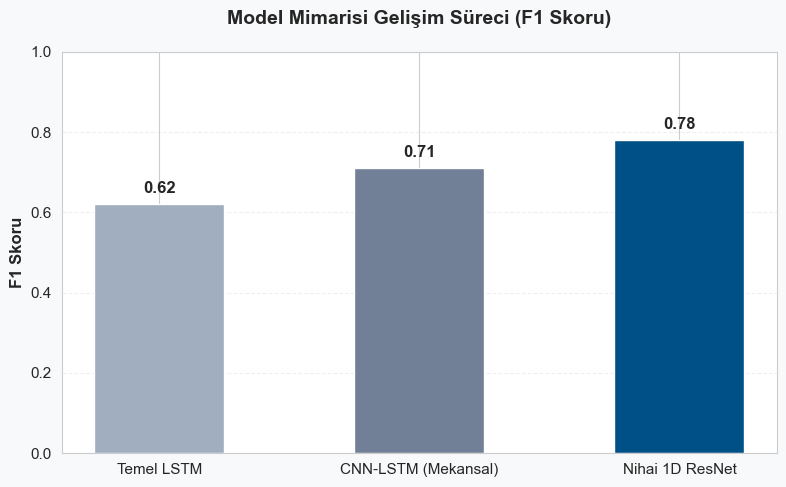

In [73]:
import matplotlib.pyplot as plt

modeller = ['Temel LSTM', 'CNN-LSTM (Mekansal)', 'Nihai 1D ResNet']
f1_skorlari = [0.62, 0.71, 0.78] 

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#f8f9fa')

bars = ax.bar(modeller, f1_skorlari, color=['#a0aec0', '#718096', '#005088'], width=0.5)

ax.set_ylabel('F1 Skoru', fontsize=12, fontweight='bold')
ax.set_title('Model Mimarisi Gelişim Süreci (F1 Skoru)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, str(yval), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

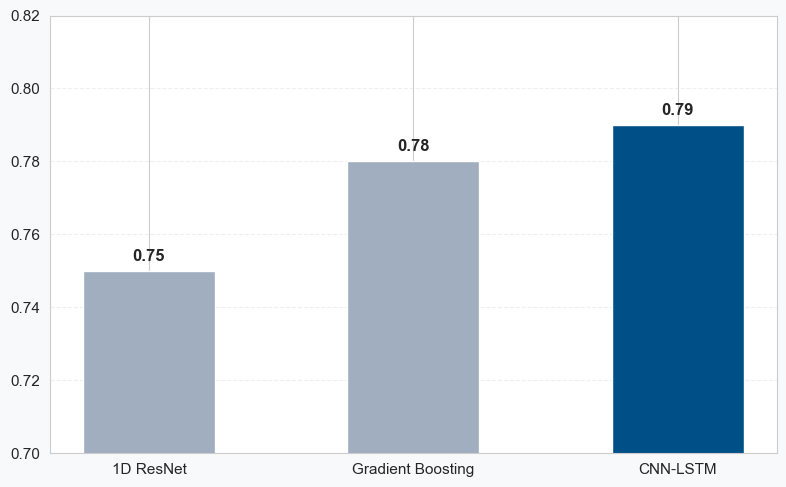

In [74]:
import matplotlib.pyplot as plt

modeller = ['1D ResNet', 'Gradient Boosting', 'CNN-LSTM']
f1_skorlari = [0.75, 0.78, 0.79]

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#f8f9fa')

renkler = ['#a0aec0', '#a0aec0', '#005088'] 
bars = ax.bar(modeller, f1_skorlari, color=renkler, width=0.5)

ax.set_ylim(0.70, 0.82) 
ax.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.002, str(yval), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

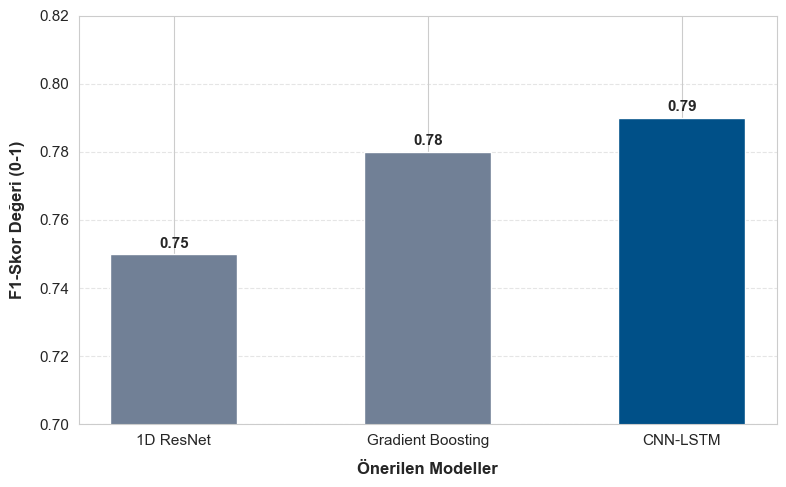

In [75]:
import matplotlib.pyplot as plt

modeller = ['1D ResNet', 'Gradient Boosting', 'CNN-LSTM']
f1_skorlari = [0.75, 0.78, 0.79]

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

bars = ax.bar(modeller, f1_skorlari, color=['#718096', '#718096', '#005088'], width=0.5)

ax.set_ylabel('F1-Skor Değeri (0-1)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlabel('Önerilen Modeller', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylim(0.70, 0.82)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.2f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

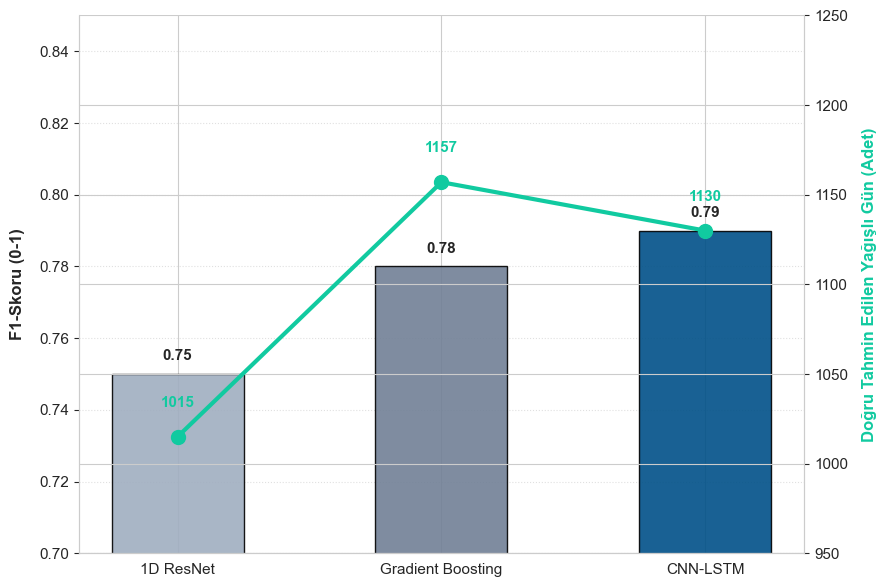

In [76]:
import matplotlib.pyplot as plt

modeller = ['1D ResNet', 'Gradient Boosting', 'CNN-LSTM']
f1_skorlari = [0.75, 0.78, 0.79]
dogru_tahmin_sayilari = [1015, 1157, 1130]

fig, ax1 = plt.subplots(figsize=(9, 6), facecolor='white')

renkler = ['#a0aec0', '#718096', '#005088'] 
bars = ax1.bar(modeller, f1_skorlari, color=renkler, width=0.5, edgecolor='black', alpha=0.9)

ax1.set_ylabel('F1-Skoru (0-1)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylim(0.70, 0.85)

ax2 = ax1.twinx()
line = ax2.plot(modeller, dogru_tahmin_sayilari, color='#11caa0', marker='o', 
                 markersize=10, linewidth=3)
ax2.set_ylabel('Doğru Tahmin Edilen Yağışlı Gün (Adet)', fontsize=12, fontweight='bold', color='#11caa0', labelpad=10)
ax2.set_ylim(950, 1250)

for i, v in enumerate(f1_skorlari):
    ax1.text(i, v + 0.003, f'{v:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for i, v in enumerate(dogru_tahmin_sayilari):
    ax2.text(i, v + 15, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold', color='#11caa0')

ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

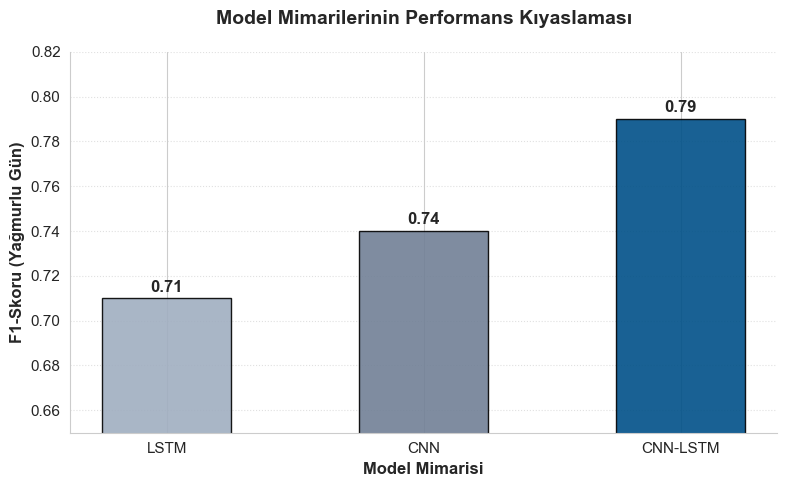

In [78]:
import matplotlib.pyplot as plt

modeller = ['LSTM', 'CNN', 'CNN-LSTM']
f1_skorlari = [0.71, 0.74, 0.79]

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

renkler = ['#a0aec0', '#718096', '#005088'] 
bars = ax.bar(modeller, f1_skorlari, color=renkler, width=0.5, edgecolor='black', alpha=0.9)

ax.set_ylabel('F1-Skoru (Yağmurlu Gün)', fontsize=12, fontweight='bold')
ax.set_xlabel('Model Mimarisi', fontsize=12, fontweight='bold')
ax.set_title('Model Mimarilerinin Performans Kıyaslaması', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0.65, 0.82)
ax.grid(axis='y', linestyle=':', alpha=0.6)

for i, v in enumerate(f1_skorlari):
    ax.text(i, v + 0.003, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


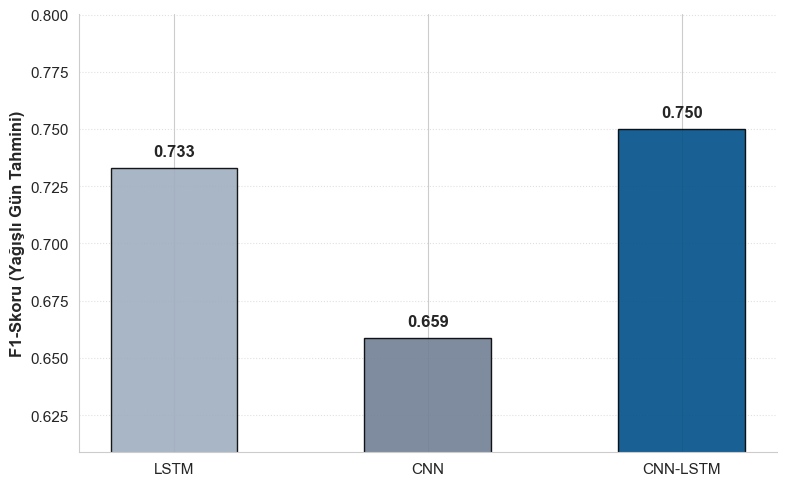

In [79]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, Dense, Dropout, Input, GlobalMaxPooling1D

results = {}

lstm_model = Sequential([
    Input(shape=(X_train_res.shape[1], X_train_res.shape[2])),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy')
lstm_model.fit(X_train_res, y_train_sp, epochs=5, batch_size=64, verbose=0)
y_pred_lstm = (lstm_model.predict(X_test_res) > 0.5).astype(int)
results['LSTM'] = f1_score(y_test_sp, y_pred_lstm)

cnn_model = Sequential([
    Input(shape=(X_train_res.shape[1], X_train_res.shape[2])),
    Conv1D(64, 3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy')
cnn_model.fit(X_train_res, y_train_sp, epochs=5, batch_size=64, verbose=0)
y_pred_cnn = (cnn_model.predict(X_test_res) > 0.5).astype(int)
results['CNN'] = f1_score(y_test_sp, y_pred_cnn)

cnn_lstm_model = Sequential([
    Input(shape=(X_train_res.shape[1], X_train_res.shape[2])),
    Conv1D(64, 3, activation='relu'),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
cnn_lstm_model.compile(optimizer='adam', loss='binary_crossentropy')
cnn_lstm_model.fit(X_train_res, y_train_sp, epochs=5, batch_size=64, verbose=0)
y_pred_hybrid = (cnn_lstm_model.predict(X_test_res) > 0.5).astype(int)
results['CNN-LSTM'] = f1_score(y_test_sp, y_pred_hybrid)

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
modeller = list(results.keys())
skorlar = list(results.values())

bars = ax.bar(modeller, skorlar, color=['#a0aec0', '#718096', '#005088'], width=0.5, edgecolor='black', alpha=0.9)

ax.set_ylabel('F1-Skoru (Yağışlı Gün Tahmini)', fontsize=12, fontweight='bold')
ax.set_ylim(min(skorlar) - 0.05, max(skorlar) + 0.05)
ax.grid(axis='y', linestyle=':', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', fontweight='bold', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

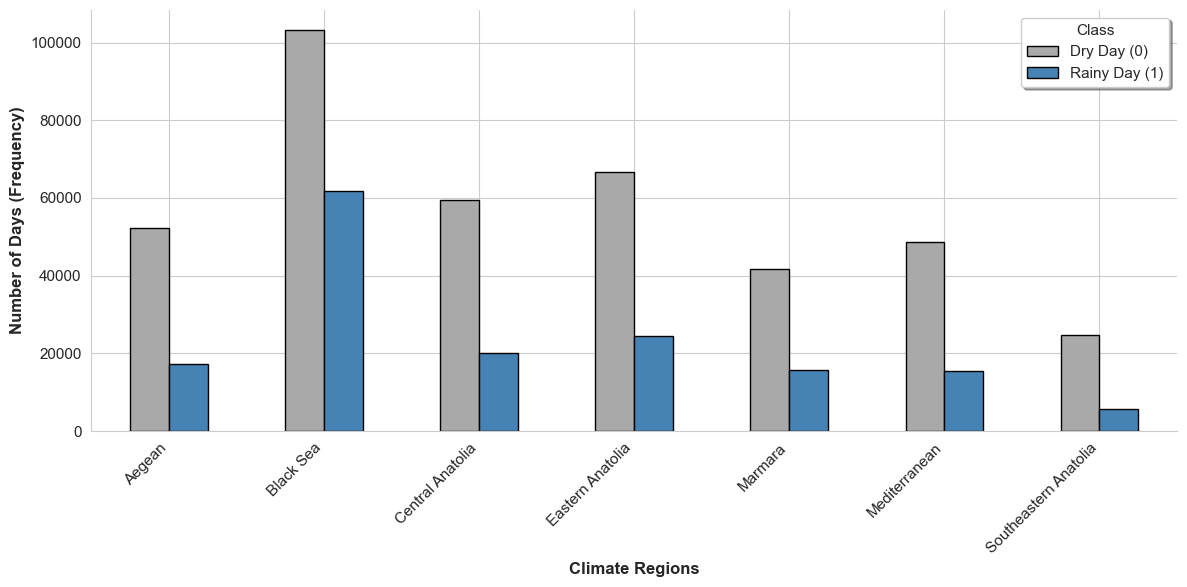

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = yeniden_temiz_omgi.copy()

df['Yagis_Durumu'] = (df['TOPLAM_YAGIS_mm'] > 0).astype(int)

region_translation = {
    'Marmara': 'Marmara',
    'Ege': 'Aegean',
    'Akdeniz': 'Mediterranean',
    'Karadeniz': 'Black Sea',
    'Ic_Anadolu': 'Central Anatolia',
    'Dogu_Anadolu': 'Eastern Anatolia',
    'Guneydogu_Anadolu': 'Southeastern Anatolia'
}
df['Iklim_Bolgesi'] = df['Iklim_Bolgesi'].map(region_translation).fillna(df['Iklim_Bolgesi'])

dagilim = df.groupby(['Iklim_Bolgesi', 'Yagis_Durumu']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

dagilim.plot(kind='bar', stacked=False, color=['#A9A9A9', '#4682B4'], ax=plt.gca(), edgecolor='black')

plt.xlabel('Climate Regions', fontsize=12, fontweight='bold')
plt.ylabel('Number of Days (Frequency)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.legend(['Dry Day (0)', 'Rainy Day (1)'], title='Class', loc='upper right', frameon=True, shadow=True)

sns.despine()
plt.tight_layout()
plt.show()

In [81]:
print(yeniden_temiz_omgi.columns)

Index(['Istasyon_No', 'Istasyon_Adi', 'YIL', 'AY', 'GUN', 'TOPLAM_YAGIS_mm',
       'Kopru_Isim', 'Iklim_Bolgesi'],
      dtype='object')


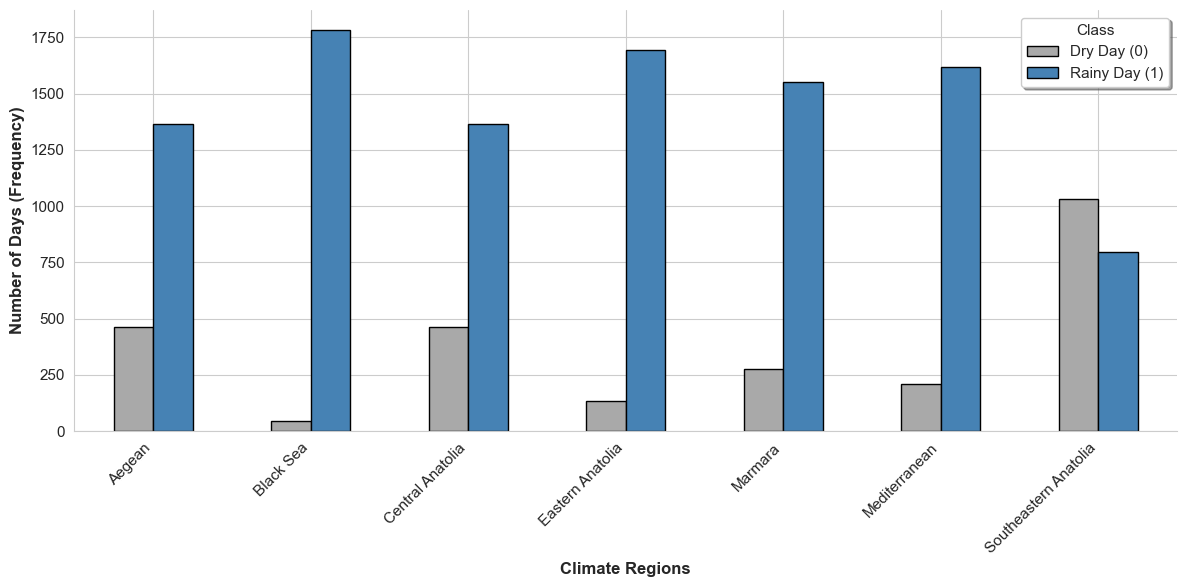

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = yeniden_temiz_omgi.copy()


bolgesel_gunluk = df.groupby(['Iklim_Bolgesi', 'YIL', 'AY', 'GUN'])['TOPLAM_YAGIS_mm'].mean().reset_index()

bolgesel_gunluk['Yagis_Durumu'] = (bolgesel_gunluk['TOPLAM_YAGIS_mm'] > 0).astype(int)

region_translation = {
    'Marmara': 'Marmara',
    'Ege': 'Aegean',
    'Akdeniz': 'Mediterranean',
    'Karadeniz': 'Black Sea',
    'Ic_Anadolu': 'Central Anatolia',
    'Dogu_Anadolu': 'Eastern Anatolia',
    'Guneydogu_Anadolu': 'Southeastern Anatolia'
}
bolgesel_gunluk['Iklim_Bolgesi'] = bolgesel_gunluk['Iklim_Bolgesi'].map(region_translation).fillna(bolgesel_gunluk['Iklim_Bolgesi'])

dagilim = bolgesel_gunluk.groupby(['Iklim_Bolgesi', 'Yagis_Durumu']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

dagilim.plot(kind='bar', stacked=False, color=['#A9A9A9', '#4682B4'], ax=plt.gca(), edgecolor='black')

plt.xlabel('Climate Regions', fontsize=12, fontweight='bold')
plt.ylabel('Number of Days (Frequency)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.legend(['Dry Day (0)', 'Rainy Day (1)'], title='Class', loc='upper right', frameon=True, shadow=True)

sns.despine()
plt.tight_layout()
plt.show()

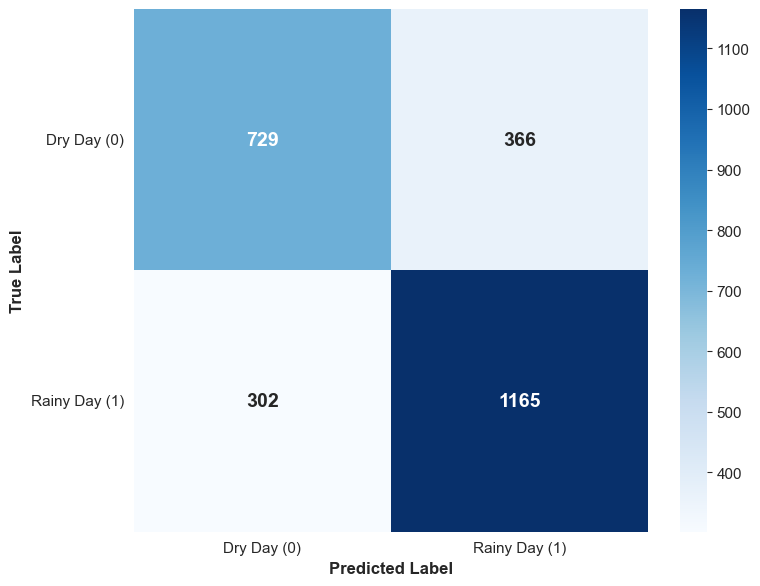

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm_final = cm_hybrid 

plt.figure(figsize=(8, 6))

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=True, 
            annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Dry Day (0)', 'Rainy Day (1)'],
            yticklabels=['Dry Day (0)', 'Rainy Day (1)'])

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

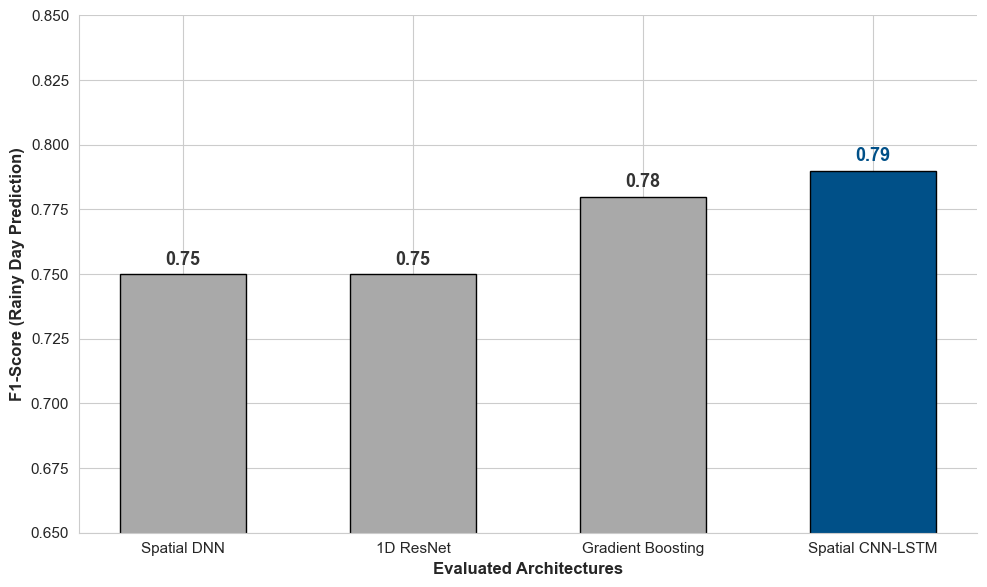

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ['Spatial DNN', '1D ResNet', 'Gradient Boosting', 'Spatial CNN-LSTM']
f1_scores = [0.75, 0.75, 0.78, 0.79]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

colors = ['#A9A9A9', '#A9A9A9', '#A9A9A9', '#005088']

bars = plt.bar(models, f1_scores, color=colors, edgecolor='black', width=0.55)

plt.xlabel('Evaluated Architectures', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score (Rainy Day Prediction)', fontsize=12, fontweight='bold')
plt.ylim(0.65, 0.85) 

for bar in bars:
    yval = bar.get_height()
    text_color = '#005088' if bar.get_facecolor()[:3] == (0.0, 0.3137254901960784, 0.5333333333333333) else '#333333'
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval:.2f}', 
             ha='center', va='bottom', fontsize=13, fontweight='bold', color=text_color)

sns.despine()
plt.tight_layout()
plt.show()

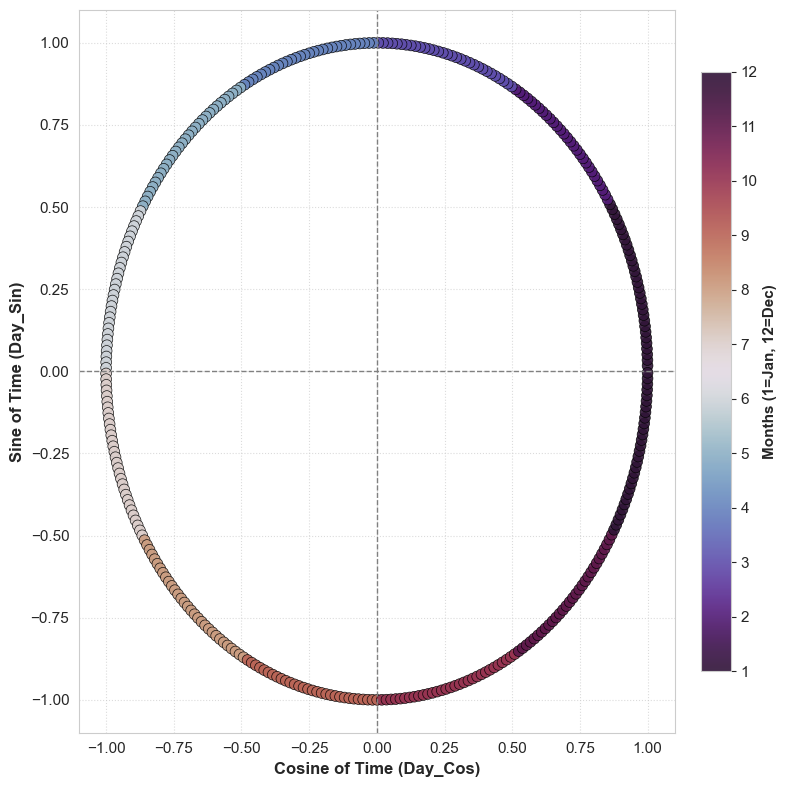

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns


ornek_zaman_df = birlestirilmis_df.head(365).copy()

plt.figure(figsize=(8, 8))

scatter = plt.scatter(ornek_zaman_df['Gun_Cos'], ornek_zaman_df['Gun_Sin'], 
                      c=ornek_zaman_df['AY'], cmap='twilight_shifted', 
                      alpha=0.9, s=60, edgecolor='k', linewidth=0.5)

cbar = plt.colorbar(scatter, ticks=range(1, 13), fraction=0.046, pad=0.04)
cbar.set_label('Months (1=Jan, 12=Dec)', fontweight='bold', fontsize=11, rotation=90)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

plt.xlabel('Cosine of Time (Day_Cos)', fontsize=12, fontweight='bold')
plt.ylabel('Sine of Time (Day_Sin)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

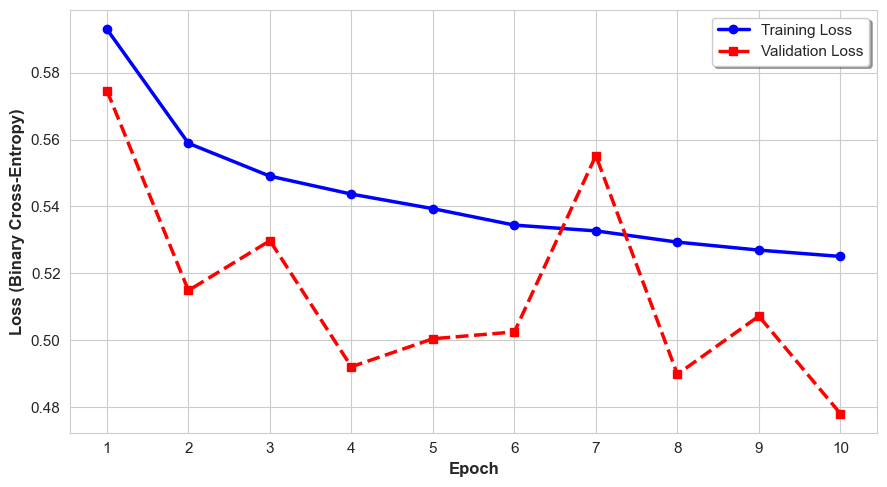

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns


egitim_kaybi = history_cnn.history['loss']
dogrulama_kaybi = history_cnn.history['val_loss']
epoch_sayisi = range(1, len(egitim_kaybi) + 1)

plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")

plt.plot(epoch_sayisi, egitim_kaybi, 'b-', marker='o', label='Training Loss', linewidth=2.5)
plt.plot(epoch_sayisi, dogrulama_kaybi, 'r--', marker='s', label='Validation Loss', linewidth=2.5)

plt.xlabel('Epoch', fontweight='bold', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontweight='bold', fontsize=12)
plt.xticks(epoch_sayisi)

plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)

plt.tight_layout()
plt.show()

In [87]:
print("-" * 60)
print(f"{'Climate Region':<25} | {'Dry Day (0)':<13} | {'Rainy Day (1)'}")
print("-" * 60)

for bolge, row in dagilim.iterrows():
    kurak_gun = int(row[0])
    yagisli_gun = int(row[1])
    print(f"{bolge:<25} | {kurak_gun:<13} | {yagisli_gun}")
print("-" * 60)

------------------------------------------------------------
Climate Region            | Dry Day (0)   | Rainy Day (1)
------------------------------------------------------------
Aegean                    | 462           | 1365
Black Sea                 | 45            | 1782
Central Anatolia          | 463           | 1364
Eastern Anatolia          | 132           | 1695
Marmara                   | 275           | 1552
Mediterranean             | 211           | 1616
Southeastern Anatolia     | 1030          | 797
------------------------------------------------------------


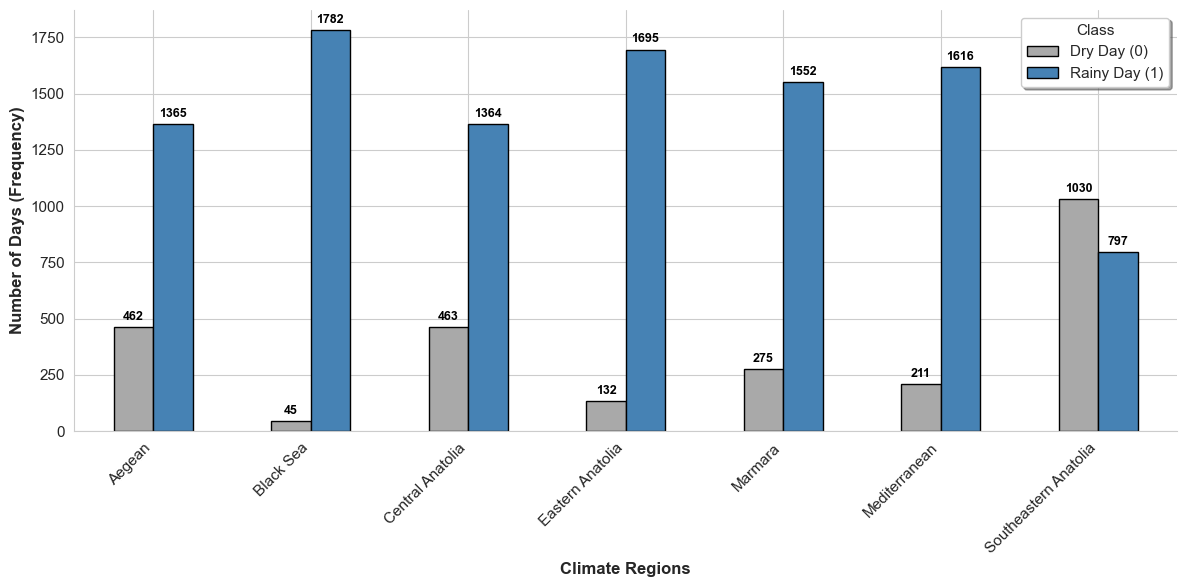

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = yeniden_temiz_omgi.copy()

bolgesel_gunluk = df.groupby(['Iklim_Bolgesi', 'YIL', 'AY', 'GUN'])['TOPLAM_YAGIS_mm'].mean().reset_index()

bolgesel_gunluk['Yagis_Durumu'] = (bolgesel_gunluk['TOPLAM_YAGIS_mm'] > 0).astype(int)

region_translation = {
    'Marmara': 'Marmara',
    'Ege': 'Aegean',
    'Akdeniz': 'Mediterranean',
    'Karadeniz': 'Black Sea',
    'Ic_Anadolu': 'Central Anatolia',
    'Dogu_Anadolu': 'Eastern Anatolia',
    'Guneydogu_Anadolu': 'Southeastern Anatolia'
}
bolgesel_gunluk['Iklim_Bolgesi'] = bolgesel_gunluk['Iklim_Bolgesi'].map(region_translation).fillna(bolgesel_gunluk['Iklim_Bolgesi'])

dagilim = bolgesel_gunluk.groupby(['Iklim_Bolgesi', 'Yagis_Durumu']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = dagilim.plot(kind='bar', stacked=False, color=['#A9A9A9', '#4682B4'], ax=plt.gca(), edgecolor='black')

plt.xlabel('Climate Regions', fontsize=12, fontweight='bold')
plt.ylabel('Number of Days (Frequency)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.legend(['Dry Day (0)', 'Rainy Day (1)'], title='Class', loc='upper right', frameon=True, shadow=True)


for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9, color='black', fontweight='bold')
# -----------------------------------------

sns.despine()
plt.tight_layout()
plt.show()